In [1]:
import kagglehub

# Download latest version
BASE= kagglehub.dataset_download("belbino/us-tariff-and-trade-war-impact-dataset-2018-present")

print("Path to dataset files:", BASE  )

100%|██████████| 67.4k/67.4k [00:00<00:00, 27.7MB/s]

Extracting files...
Path to dataset files: /root/.cache/kagglehub/datasets/belbino/us-tariff-and-trade-war-impact-dataset-2018-present/versions/5


In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import matplotlib.dates as mdates
import plotly.express as px
import plotly.graph_objects as go
import matplotlib.patches as mpatches
from matplotlib.gridspec import GridSpec
import os # Import os module
mkt   = pd.read_csv(os.path.join(BASE, 'market_reaction.csv'), parse_dates=['date'])
rates = pd.read_csv(os.path.join(BASE, 'tariff_rates.csv'),         parse_dates=['date'])
news  = pd.read_csv(os.path.join(BASE, 'tariff_news_headlines.csv'), parse_dates=['date'])
tb    = pd.read_csv(os.path.join(BASE, 'trade_balance.csv'))

In [3]:
mkt.head()

,date,sp500,shanghai_composite,dxy,usd_cny,crude_oil_wti,steel_futures,aluminum_futures,soybeans
0,2020-01-02,3257.850098,3085.197998,96.849998,0.143633,61.180000,587.0,1812.50,944.25
1,2020-01-03,3234.850098,3083.785889,96.839996,0.143608,63.049999,590.0,1830.00,930.50
2,2020-01-06,3246.280029,3083.407959,96.669998,0.143585,63.270000,586.0,1842.00,932.75
3,2020-01-07,3237.179932,3104.802002,96.980003,0.143379,62.700001,591.0,1822.00,935.00
4,2020-01-08,3253.050049,3066.893066,97.300003,0.144001,59.610001,581.0,1802.75,938.25


In [4]:
rates.head()

,date,country,product_category,tariff_rate_pct,announcement_source,headline,url
0,2018-03-08,Global,Steel,25.0,Section 232,Trump signs 25% steel tariffs under Section 232,NaN
1,2018-03-08,Global,Aluminum,10.0,Section 232,Trump signs 10% aluminum tariffs under Section...,NaN
2,2018-07-06,China,Tech/Industrial,25.0,Section 301,US imposes 25% tariffs on $34B of Chinese tech...,NaN
3,2019-09-01,China,Consumer Goods,15.0,Section 301,New 15% tariffs on Chinese consumer goods take...,NaN
4,2020-01-15,China,Phase 1 Deal,7.5,Phase 1 Agreement,US reduces China tariffs to 7.5% under Phase 1...,NaN


In [5]:
news.head()

,date,headline,source,sentiment,url
0,2026-04-15,South Korea Has An Oil Problem. Canada Is Help...,OilPrice.com,Neutral,https://oilprice.com/Energy/Crude-Oil/South-Ko...
1,2026-04-15,Kerrygold-maker Ornua reports rise in turnover...,RTE,Neutral,https://www.rte.ie/news/business/2026/0415/156...
2,2026-04-15,"Trump Declares ‘Decisive’ Victory, but Who Rea...",Activistpost.com,Positive,https://www.activistpost.com/trump-declares-de...
3,2026-04-15,Mint Quick Edit | China took an export blow in...,Livemint,Neutral,https://www.livemint.com/opinion/online-views/...
4,2026-04-15,Reading Trump’s Foreign Policy Through Hunting...,Globalresearch.ca,Negative,https://www.globalresearch.ca/trump-foreign-po...


In [6]:
tb.head()

,date,us_trade_balance_bn
0,2020-01,-43562
1,2020-02,-39931
2,2020-03,-42374
3,2020-04,-51888
4,2020-05,-53995


In [7]:
tb['date']       = pd.to_datetime(tb['date'])
tb['balance_bn'] = tb['us_trade_balance_bn'] / 1000
mkt   = mkt.sort_values('date').reset_index(drop=True)
rates = rates.sort_values('date').reset_index(drop=True)

# Define colors
GREEN = 'green'
BLUE = 'blue'
YELLOW = 'yellow'
ORANGE = 'orange'
RED = 'red'
PURPLE = 'purple'
CYAN = 'cyan'
SUBTEXT = '#a1a1aa'
TEXT = '#f4f4f5'
DARK_BG = '#0f172a'

KEY_EVENTS = {
    '2020-01-15': ('Phase 1 Deal',    GREEN),
    '2024-05-14': ('Biden EV 100%',   BLUE),
    '2025-02-01': ('China +10%',      YELLOW),
    '2025-03-04': ('CA/MX +25%',      ORANGE),
    '2025-04-02': ('Liberation Day',  RED),
    '2025-04-09': ('China 145%',      '#dc2626'),
}
KEY_DATES = [pd.to_datetime(d) for d in KEY_EVENTS]

# Live snapshot
latest = mkt.iloc[-1]
print(f"{'='*55}")
print(f"  📡 LIVE DATA SNAPSHOT  —  {latest['date'].date()}")
print(f"{'='*55}")
print(f"  S&P 500:       {latest['sp500']:>10,.1f}")
print(f"  Shanghai:      {latest['shanghai_composite']:>10,.1f}")
print(f"  Crude Oil:     {latest['crude_oil_wti']:>10.2f} $/bbl")
print(f"  Steel Futures: {latest['steel_futures']:>10.1f} $/ton")
print(f"  Soybeans:      {latest['soybeans']:>10.2f} c/bu")
print(f"  USD Index:     {latest['dxy']:>10.2f}")
print(f"{'='*55}")
print(f"  📋 Tariff events tracked:  {len(rates)}")
print(f"  📰 News headlines:         {len(news)}")
print(f"  📅 Market data rows:       {len(mkt):,} ({mkt.date.min().date()} → {mkt.date.max().date()})")
print(f"  📉 Latest trade deficit:   ${tb.balance_bn.iloc[-1]:.1f}B ({tb.date.iloc[-1].strftime('%b %Y')})")

  📡 LIVE DATA SNAPSHOT  —  2026-04-15
  S&P 500:          7,023.0
  Shanghai:         4,027.2
  Crude Oil:          91.29 $/bbl
  Steel Futures:     1046.0 $/ton
  Soybeans:         1167.00 c/bu
  USD Index:          98.06
  📋 Tariff events tracked:  29
  📰 News headlines:         97
  📅 Market data rows:       1,579 (2020-01-02 → 2026-04-15)
  📉 Latest trade deficit:   $-57.3B (Feb 2026)


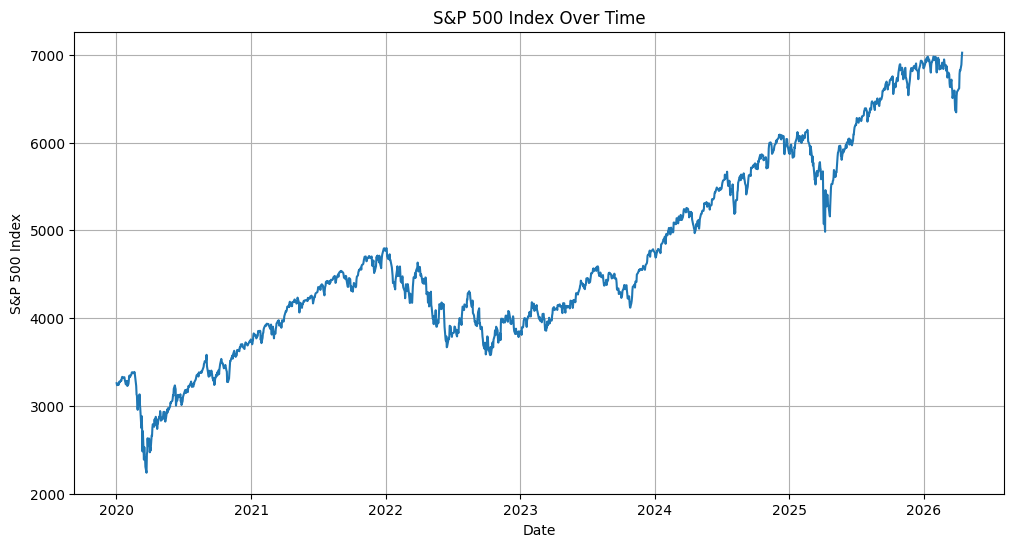

In [8]:
plt.figure(figsize=(12, 6))
sns.lineplot(x='date', y='sp500', data=mkt)
plt.title('S&P 500 Index Over Time')
plt.xlabel('Date')
plt.ylabel('S&P 500 Index')
plt.grid(True)
plt.show()

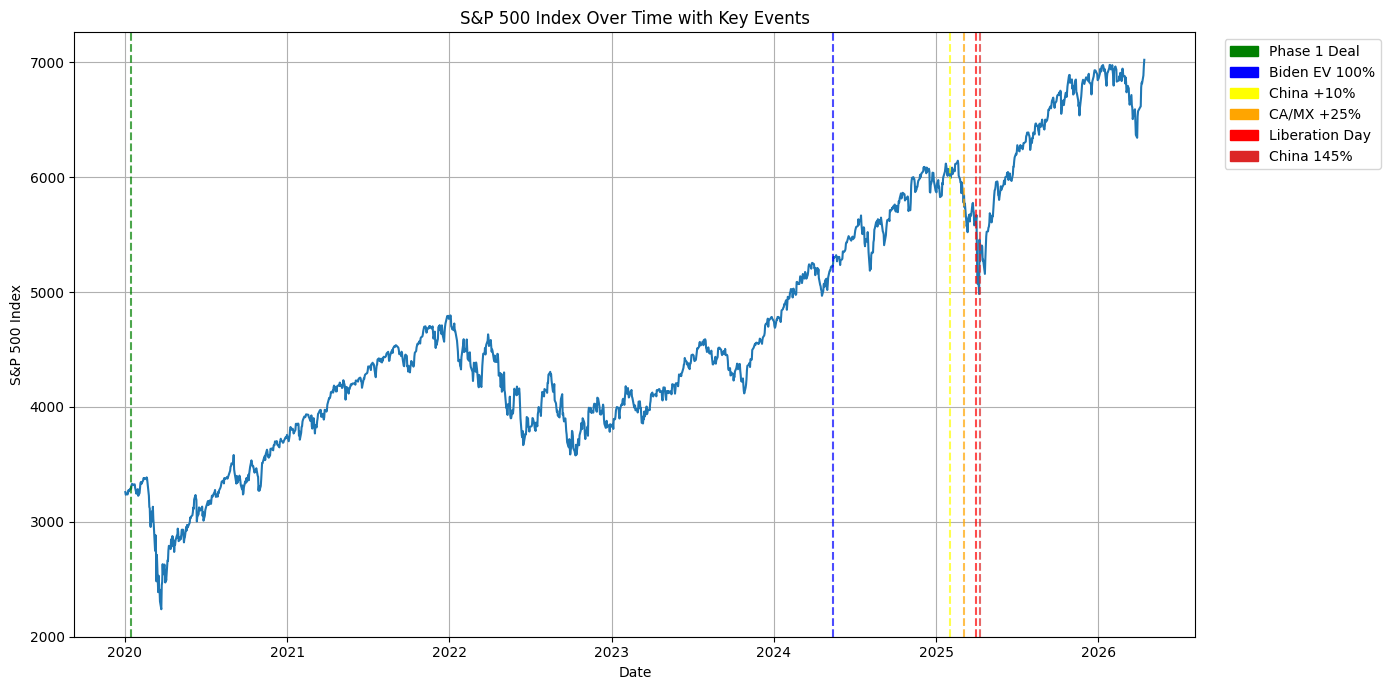

In [9]:


plt.figure(figsize=(14, 7))
sns.lineplot(x='date', y='sp500', data=mkt, label='S&P 500 Index')

# Overlay KEY_EVENTS
legend_patches = []
for date_str, (event_name, color) in KEY_EVENTS.items():
    event_date = pd.to_datetime(date_str)
    plt.axvline(x=event_date, color=color, linestyle='--', alpha=0.7)
    legend_patches.append(mpatches.Patch(color=color, label=event_name))

plt.title('S&P 500 Index Over Time with Key Events')
plt.xlabel('Date')
plt.ylabel('S&P 500 Index')
plt.grid(True)
plt.legend(handles=legend_patches, loc='upper left', bbox_to_anchor=(1.02, 1))
plt.tight_layout()
plt.show()

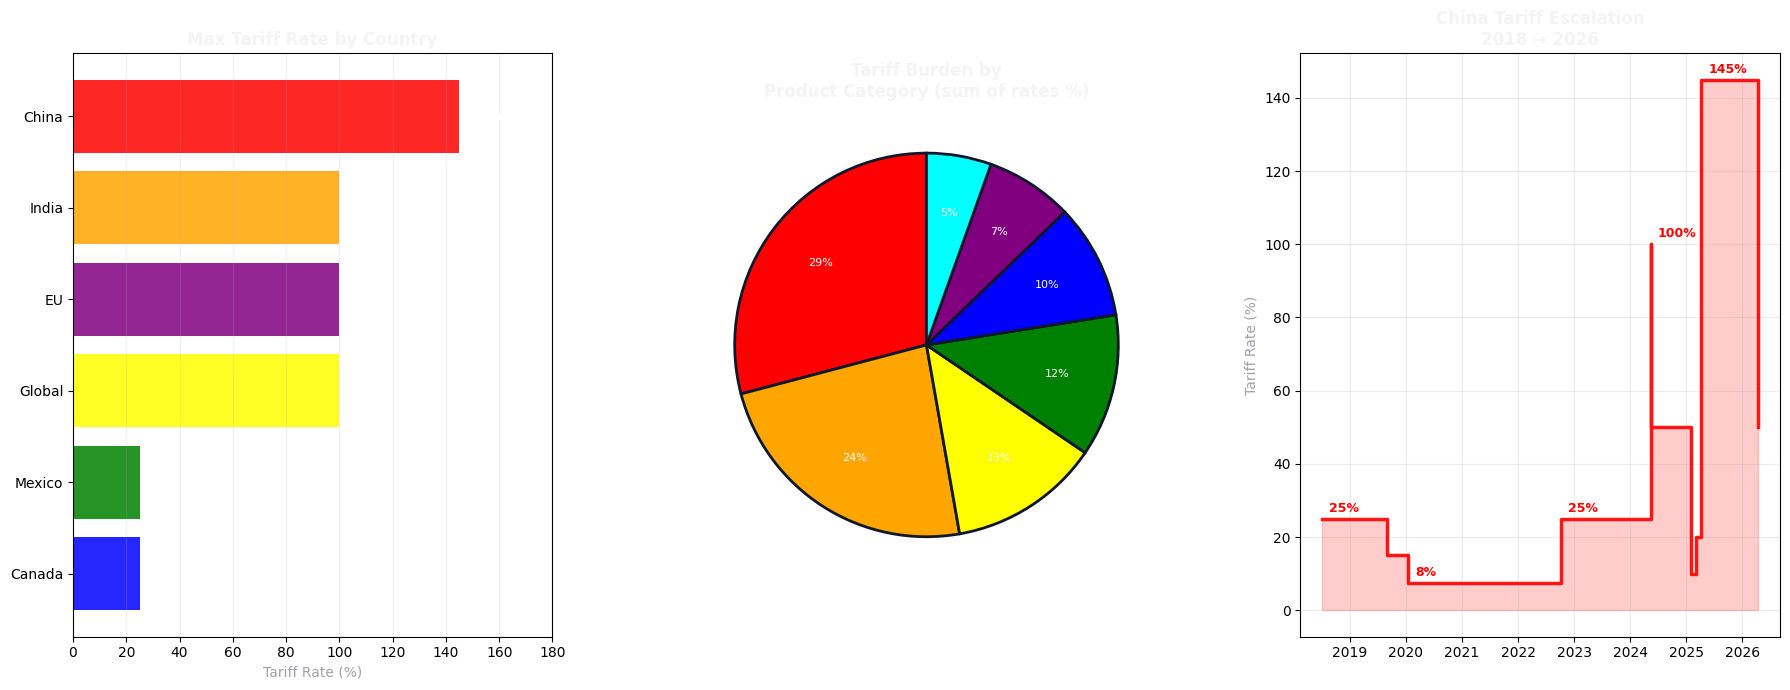

🇨🇳 China: 0% (2017) → 145% (2025) in just 8 years - largest tariff escalation in modern history
🇨🇦 Canada: reached 25% - unprecedented for a USMCA partner
🌐 Global: 10% baseline applied to ALL countries on Liberation Day (Apr 2025)


In [10]:
fig, axes = plt.subplots(1, 3, figsize=(18, 7))

# Left: Max tariff by country
country_max = rates.groupby('country')['tariff_rate_pct'].max().sort_values(ascending=True)

country_colors = {'China':RED,'Global':YELLOW,'Canada':BLUE,'Mexico':GREEN,'EU':PURPLE,'India':ORANGE}
colors_bar  = [country_colors.get(c, SUBTEXT) for c in country_max.index]

axes[0].barh(country_max.index, country_max.values, color=colors_bar, alpha=0.85)
for i, (val, lbl) in enumerate(zip(country_max.values, country_max.index)):
    axes[0].text(val + 1, i, f'{val:.0f}%', va='center', fontsize=10, color='white', fontweight='bold')
axes[0].set_title('Max Tariff Rate by Country', fontsize=12, fontweight='bold', color=TEXT)
axes[0].set_xlabel('Tariff Rate (%)', color=SUBTEXT)
axes[0].grid(True, alpha=0.2, axis='x')
axes[0].set_xlim(0, 180)

# Middle: product category donut
cat_counts = rates.groupby('product_category')['tariff_rate_pct'].sum().sort_values(ascending=False).head(7)
cat_colors = [RED, ORANGE, YELLOW, GREEN, BLUE, PURPLE, CYAN]

wedges, texts, autotexts = axes[1].pie(
    cat_counts.values, labels=cat_counts.index, colors=cat_colors,
    autopct='%1.0f%%', pctdistance=0.7, startangle=90,
    wedgeprops=dict(edgecolor='#0f172a', linewidth=2),
    textprops=dict(color='white', fontsize=9)
)
for at in autotexts: at.set_fontsize(8); at.set_color('white')
axes[1].set_title('Tariff Burden by\nProduct Category (sum of rates %)',
                 fontsize=12, fontweight='bold', color=TEXT)

# Right: escalation timeline for China
china_r = rates[rates['country']=='China'].copy()
axes[2].step(china_r['date'], china_r['tariff_rate_pct'], where='post',
            color=RED, lw=2.5, alpha=0.9)
axes[2].fill_between(china_r['date'], 0, china_r['tariff_rate_pct'],
                    step='post', alpha=0.2, color=RED)

# Annotate key milestones
for _, row in china_r.iterrows():
    if row['tariff_rate_pct'] in [7.5, 25, 100, 145]:
        axes[2].annotate(f"{row['tariff_rate_pct']:.0f}%",
                        xy=(row['date'], row['tariff_rate_pct']),
                        xytext=(5, 5), textcoords='offset points',
                        color=RED, fontsize=9, fontweight='bold')

axes[2].set_title('China Tariff Escalation\n2018 → 2026', fontsize=12, fontweight='bold', color=TEXT)
axes[2].set_ylabel('Tariff Rate (%)', color=SUBTEXT)
axes[2].grid(True, alpha=0.25)
axes[2].xaxis.set_major_formatter(mdates.DateFormatter('%Y'))

plt.tight_layout()
plt.savefig('country_impact.png', dpi=150, bbox_inches='tight', facecolor=DARK_BG)
plt.show()

print(f"🇨🇳 China: 0% (2017) → 145% (2025) in just 8 years - largest tariff escalation in modern history")
print(f"🇨🇦 Canada: reached 25% - unprecedented for a USMCA partner")
print(f"🌐 Global: 10% baseline applied to ALL countries on Liberation Day (Apr 2025)")

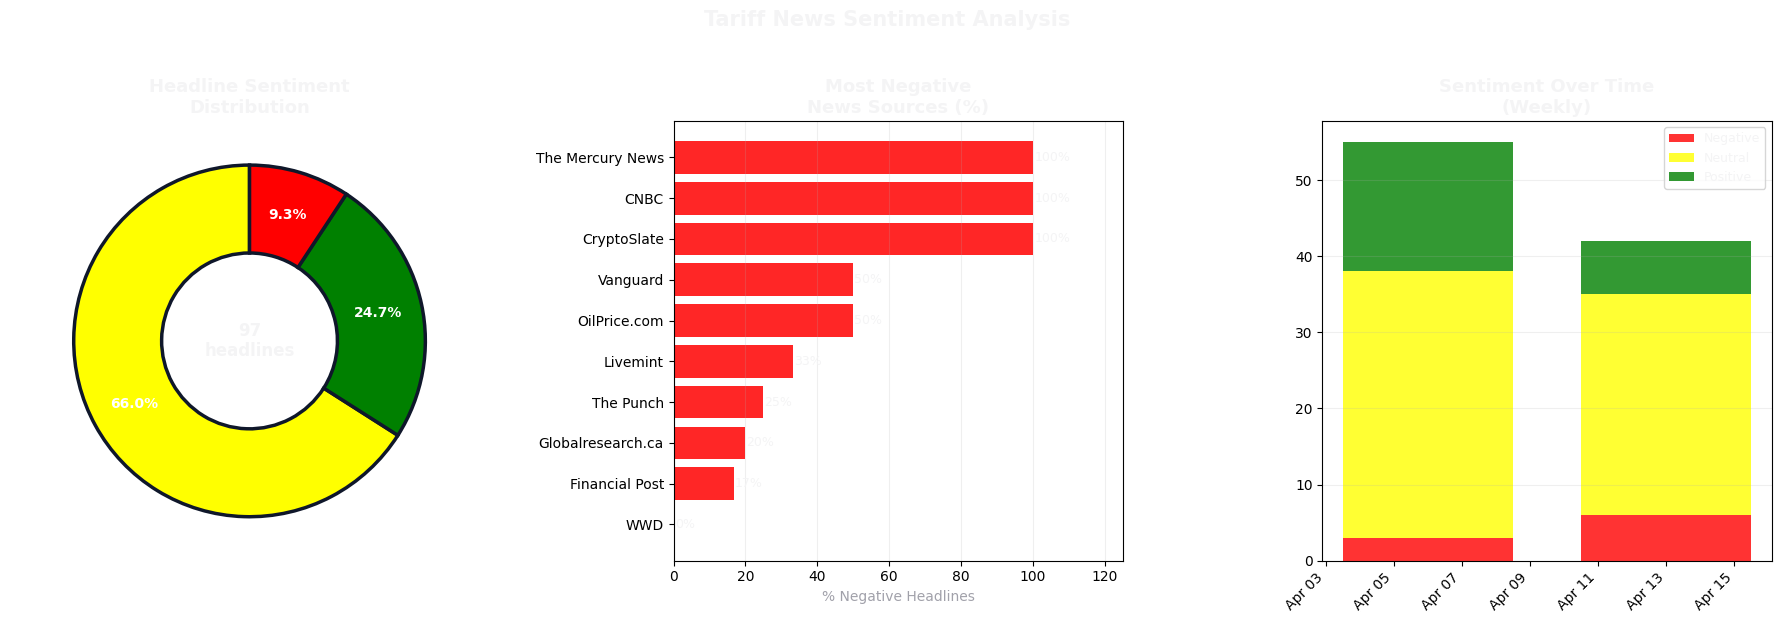

📰 Sentiment breakdown: Neutral 64 | Positive 24 | Negative 9

💡 Most coverage is Neutral — tariff news is reported factually, not emotionally
   Only 9% negative headlines
   → Suggests market panic comes from interpretation, not the headlines themselves


In [11]:
fig, axes = plt.subplots(1, 3, figsize=(18, 6))

# Left: sentiment donut
svals   = news['sentiment'].value_counts()
s_colors = {'Positive': GREEN, 'Neutral': YELLOW, 'Negative': RED}
scols   = [s_colors.get(s, SUBTEXT) for s in svals.index]

wedges, texts, autotexts = axes[0].pie(
    svals.values, labels=svals.index, colors=scols, autopct='%1.1f%%',
    startangle=90, pctdistance=0.75,
    wedgeprops=dict(edgecolor='#0f172a', linewidth=2.5, width=0.5),
    textprops=dict(color='white', fontsize=12, fontweight='bold')
)
for at in autotexts: at.set_fontsize(10); at.set_color('white')
axes[0].set_title('Headline Sentiment\nDistribution', fontsize=13, fontweight='bold', color=TEXT)
total = len(news)
axes[0].text(0, 0, f'{total}\nheadlines', ha='center', va='center',
            fontsize=12, color=TEXT, fontweight='bold')

# Middle: sources with most negative coverage
source_sent = news.groupby('source')['sentiment'].apply(
    lambda x: (x == 'Negative').sum() / len(x) * 100
).sort_values(ascending=True).tail(10)

bar_cols = [RED if v > 15 else ORANGE if v > 8 else YELLOW for v in source_sent.values]
axes[1].barh(source_sent.index, source_sent.values, color=bar_cols, alpha=0.85)
for i, v in enumerate(source_sent.values):
    axes[1].text(v + 0.3, i, f'{v:.0f}%', va='center', fontsize=9, color=TEXT)
axes[1].set_title('Most Negative\nNews Sources (%)', fontsize=13, fontweight='bold', color=TEXT)
axes[1].set_xlabel('% Negative Headlines', color=SUBTEXT)
axes[1].grid(True, alpha=0.2, axis='x')
axes[1].set_xlim(0, max(source_sent.values) * 1.25)

# Right: Sentiment over time (stacked bar)
news['week'] = news['date'].dt.to_period('W').dt.start_time
sent_time = news.groupby(['week','sentiment']).size().unstack(fill_value=0)
for s in ['Negative','Neutral','Positive']:
    if s not in sent_time: sent_time[s] = 0

bottom_n = np.zeros(len(sent_time))
bottom_p = sent_time.get('Negative', 0).values.astype(float)
bottom_2 = bottom_p + sent_time.get('Neutral', 0).values.astype(float)

axes[2].bar(sent_time.index, sent_time.get('Negative', pd.Series(0, index=sent_time.index)).values,
           bottom=bottom_n, color=RED, alpha=0.8, label='Negative', width=5)
axes[2].bar(sent_time.index, sent_time.get('Neutral', pd.Series(0, index=sent_time.index)).values,
           bottom=bottom_p, color=YELLOW, alpha=0.8, label='Neutral', width=5)
axes[2].bar(sent_time.index, sent_time.get('Positive', pd.Series(0, index=sent_time.index)).values,
           bottom=bottom_2, color=GREEN, alpha=0.8, label='Positive', width=5)

axes[2].set_title('Sentiment Over Time\n(Weekly)', fontsize=13, fontweight='bold', color=TEXT)
axes[2].legend(labelcolor=TEXT, fontsize=9)
axes[2].grid(True, alpha=0.2, axis='y')
axes[2].xaxis.set_major_formatter(mdates.DateFormatter('%b %d'))
plt.setp(axes[2].xaxis.get_majorticklabels(), rotation=45, ha='right')

plt.suptitle('Tariff News Sentiment Analysis', fontsize=15, fontweight='bold', color=TEXT, y=1.03)
plt.tight_layout()
plt.savefig('sentiment.png', dpi=150, bbox_inches='tight', facecolor=DARK_BG)
plt.show()

print(f"📰 Sentiment breakdown: Neutral {(news.sentiment=='Neutral').sum()} | "
      f"Positive {(news.sentiment=='Positive').sum()} | Negative {(news.sentiment=='Negative').sum()}")
print(f"\n💡 Most coverage is Neutral — tariff news is reported factually, not emotionally")
print(f"   Only {(news.sentiment=='Negative').sum()/len(news)*100:.0f}% negative headlines")
print(f"   → Suggests market panic comes from interpretation, not the headlines themselves")


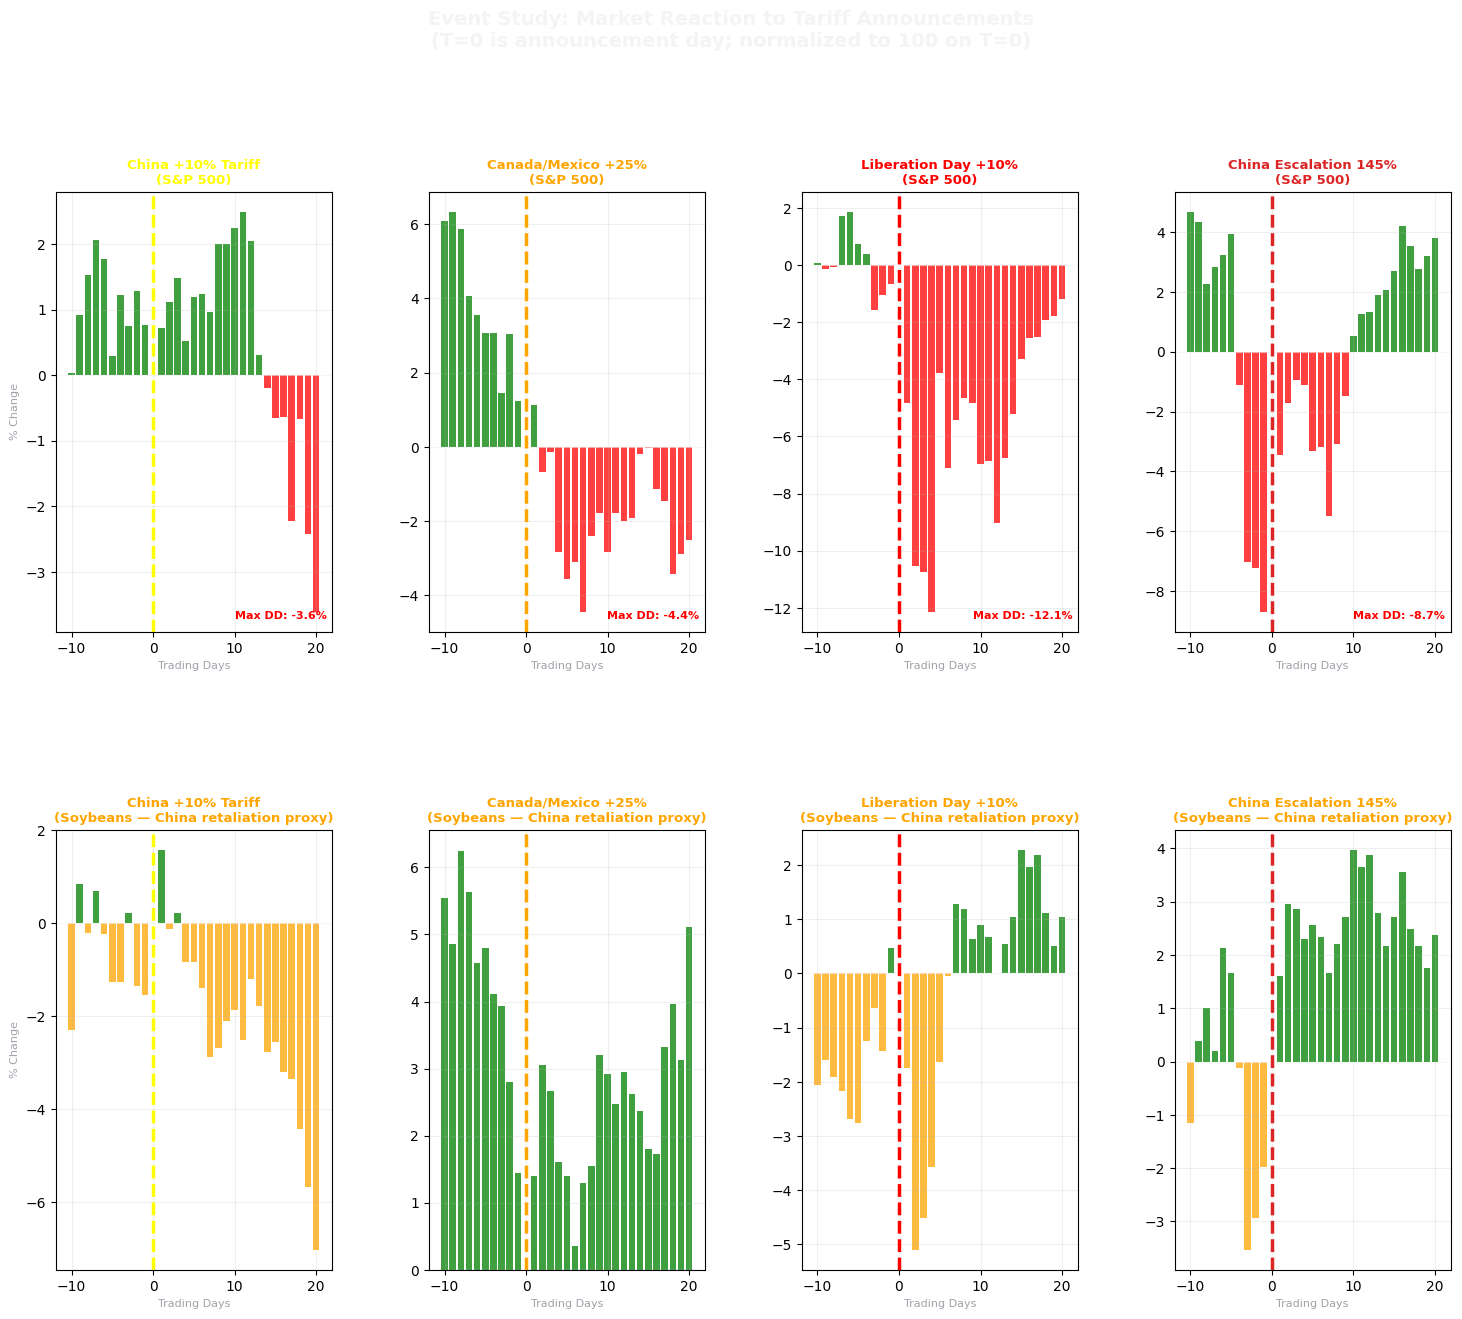

📊 Cumulative Abnormal Returns (CAR) — S&P 500
Event                               T+1      T+5     T+10     T+20
--------------------------------------------------------------
China +10% Tariff                 0.7%    1.2%    2.3%   -3.6%
Canada/Mexico +25%                1.1%   -3.6%   -2.8%   -2.5%
Liberation Day +10%              -4.8%   -3.8%   -7.0%   -1.2%
China Escalation 145%            -3.5%   -3.3%    0.5%    3.8%


In [12]:
study_events = {
    '2025-02-01': ('China +10% Tariff',     YELLOW),
    '2025-03-04': ('Canada/Mexico +25%',    ORANGE),
    '2025-04-02': ('Liberation Day +10%',   RED),
    '2025-04-09': ('China Escalation 145%', '#dc2626'),
}

fig = plt.figure(figsize=(18, 14))
fig.suptitle('Event Study: Market Reaction to Tariff Announcements\n'
             '(T=0 is announcement day; normalized to 100 on T=0)',
             fontsize=14, fontweight='bold', color=TEXT, y=1.01)

gs = GridSpec(2, 4, figure=fig, hspace=0.45, wspace=0.35)

for col_idx, (evt_date, (evt_label, evt_color)) in enumerate(study_events.items()):
    evt_dt = pd.to_datetime(evt_date)
    idx = mkt['date'].searchsorted(evt_dt)

    win_s = max(0, idx - 10)
    win_e = min(len(mkt), idx + 21)
    t_offset = idx - win_s

    # S&P 500 (top row)
    ax_sp = fig.add_subplot(gs[0, col_idx])
    sp = mkt['sp500'].iloc[win_s:win_e].reset_index(drop=True)
    t  = np.arange(-t_offset, len(sp) - t_offset)
    t0_sp = sp.iloc[t_offset]
    norm_sp = (sp / t0_sp - 1) * 100

    ax_sp.bar(t, norm_sp.values, color=[GREEN if v>=0 else RED for v in norm_sp], alpha=0.75)
    ax_sp.axhline(0, color='white', lw=0.8, alpha=0.5)
    ax_sp.axvline(0, color=evt_color, lw=2.5, ls='--', label='Announcement')

    max_dd = norm_sp.min()
    max_up = norm_sp.max()
    ax_sp.set_title(f'{evt_label}\n(S&P 500)', fontsize=9.5, fontweight='bold', color=evt_color)
    ax_sp.text(0.98, 0.03, f'Max DD: {max_dd:.1f}%', transform=ax_sp.transAxes,
              ha='right', fontsize=8, color=RED, fontweight='bold')
    ax_sp.grid(True, alpha=0.2)
    ax_sp.set_xlabel('Trading Days', fontsize=8, color=SUBTEXT)
    if col_idx == 0: ax_sp.set_ylabel('% Change', fontsize=8, color=SUBTEXT)

    # Soybeans (bottom row) — China retaliation proxy
    ax_sb = fig.add_subplot(gs[1, col_idx])
    sb = mkt['soybeans'].iloc[win_s:win_e].reset_index(drop=True)
    t0_sb = sb.iloc[t_offset]
    norm_sb = (sb / t0_sb - 1) * 100

    ax_sb.bar(t, norm_sb.values, color=[GREEN if v>=0 else ORANGE for v in norm_sb], alpha=0.75)
    ax_sb.axhline(0, color='white', lw=0.8, alpha=0.5)
    ax_sb.axvline(0, color=evt_color, lw=2.5, ls='--')
    ax_sb.set_title(f'{evt_label}\n(Soybeans — China retaliation proxy)', fontsize=9.5, fontweight='bold', color=ORANGE)
    ax_sb.grid(True, alpha=0.2)
    ax_sb.set_xlabel('Trading Days', fontsize=8, color=SUBTEXT)
    if col_idx == 0: ax_sb.set_ylabel('% Change', fontsize=8, color=SUBTEXT)

plt.savefig('event_study.png', dpi=150, bbox_inches='tight', facecolor=DARK_BG)
plt.show()

# Compute CAR table
print("📊 Cumulative Abnormal Returns (CAR) — S&P 500")
print(f"{'Event':<30} {'T+1':>8} {'T+5':>8} {'T+10':>8} {'T+20':>8}")
print('-'*62)
for evt_date, (evt_label, _) in study_events.items():
    evt_dt = pd.to_datetime(evt_date)
    idx = mkt['date'].searchsorted(evt_dt)
    t0_val = mkt['sp500'].iloc[idx]
    for lag, col_name in [(1, 'T+1'), (5, 'T+5'), (10, 'T+10'), (20, 'T+20')]:
        target_idx = min(idx + lag, len(mkt)-1)
        change = (mkt['sp500'].iloc[target_idx] / t0_val - 1) * 100
        if col_name == 'T+1':
            row = f"{evt_label:<30}"
        row += f"{change:>7.1f}%"
    print(row)

/tmp/ipykernel_8899/1585823224.py:59: UserWarning: Glyph 128200 (\N{CHART WITH UPWARDS TREND}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_8899/1585823224.py:60: UserWarning: Glyph 128200 (\N{CHART WITH UPWARDS TREND}) missing from font(s) DejaVu Sans.
  plt.savefig('rolling_dynamics.png', dpi=150, bbox_inches='tight', facecolor=DARK_BG)
/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 128200 (\N{CHART WITH UPWARDS TREND}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


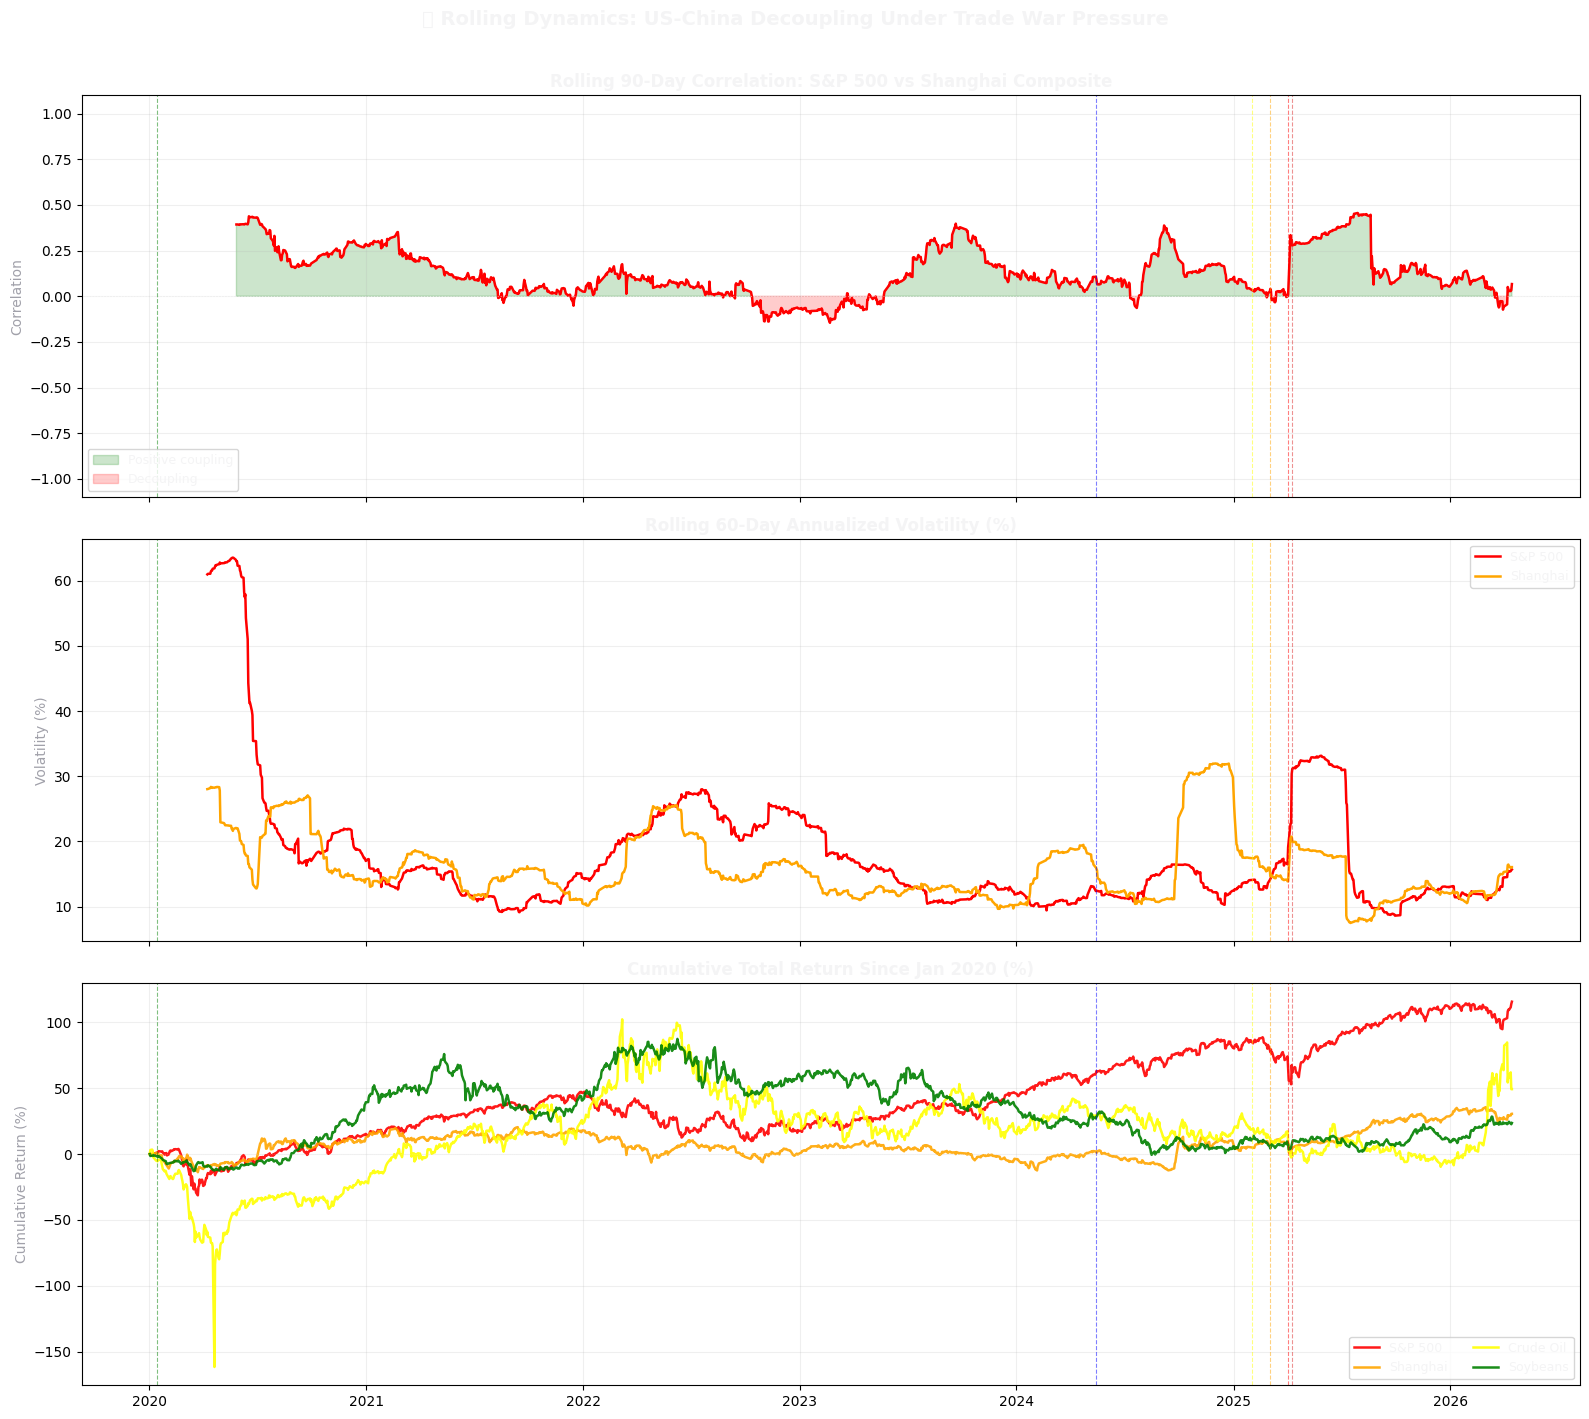

📊 US-China market correlation:
   2020–2021 avg: 0.178
   2025–2026 avg: 0.164
   → -1.4pp change - markets are decoupling!


In [13]:
mkt_clean = mkt.set_index('date')[['sp500','shanghai_composite','crude_oil_wti','soybeans']].dropna()
rets = mkt_clean.pct_change().dropna()
fig, axes = plt.subplots(3, 1, figsize=(16, 14), sharex=True)
roll_corr = rets['sp500'].rolling(90).corr(rets['shanghai_composite'])
axes[0].plot(roll_corr.index, roll_corr, color=RED, lw=1.8)
axes[0].fill_between(roll_corr.index, 0, roll_corr,
                    where=roll_corr > 0, alpha=0.2, color=GREEN, label='Positive coupling')
axes[0].fill_between(roll_corr.index, 0, roll_corr,
                    where=roll_corr <= 0, alpha=0.2, color=RED, label='Decoupling')
axes[0].axhline(0, color='white', lw=0.8, alpha=0.5, ls=':')

for evt_date, (lbl, color) in KEY_EVENTS.items():
    evt_dt = pd.to_datetime(evt_date)
    axes[0].axvline(evt_dt, color=color, lw=0.8, alpha=0.5, ls='--')

axes[0].set_title('Rolling 90-Day Correlation: S&P 500 vs Shanghai Composite',
                 fontsize=12, fontweight='bold', color=TEXT)
axes[0].set_ylabel('Correlation', color=SUBTEXT)
axes[0].legend(labelcolor=TEXT, fontsize=9, loc='lower left')
axes[0].grid(True, alpha=0.2)
axes[0].set_ylim(-1.1, 1.1)

# Panel 2: Rolling volatility (annualized)
sp_vol   = rets['sp500'].rolling(60).std() * np.sqrt(252) * 100
shang_vol = rets['shanghai_composite'].rolling(60).std() * np.sqrt(252) * 100

axes[1].plot(sp_vol.index, sp_vol, color=RED, lw=1.8, label='S&P 500')
axes[1].plot(shang_vol.index, shang_vol, color=ORANGE, lw=1.8, label='Shanghai')

for evt_date, (lbl, color) in KEY_EVENTS.items():
    evt_dt = pd.to_datetime(evt_date)
    axes[1].axvline(evt_dt, color=color, lw=0.8, alpha=0.5, ls='--')

axes[1].set_title('Rolling 60-Day Annualized Volatility (%)', fontsize=12, fontweight='bold', color=TEXT)
axes[1].set_ylabel('Volatility (%)', color=SUBTEXT)
axes[1].legend(labelcolor=TEXT, fontsize=9)
axes[1].grid(True, alpha=0.2)

# Panel 3: Cumulative performance
for col, lbl, color in [('sp500','S&P 500',RED), ('shanghai_composite','Shanghai',ORANGE),
                         ('crude_oil_wti','Crude Oil',YELLOW), ('soybeans','Soybeans',GREEN)]:
    s = mkt.set_index('date')[col].dropna()
    cum = (s / s.iloc[0] - 1) * 100
    axes[2].plot(cum.index, cum, color=color, lw=1.8, label=lbl, alpha=0.9)

for evt_date, (lbl, color) in KEY_EVENTS.items():
    evt_dt = pd.to_datetime(evt_date)
    axes[2].axvline(evt_dt, color=color, lw=0.8, alpha=0.5, ls='--')

axes[2].axhline(0, color='white', lw=0.5, alpha=0.3, ls=':')
axes[2].set_title('Cumulative Total Return Since Jan 2020 (%)', fontsize=12, fontweight='bold', color=TEXT)
axes[2].set_ylabel('Cumulative Return (%)', color=SUBTEXT)
axes[2].legend(labelcolor=TEXT, fontsize=9, ncol=2)
axes[2].grid(True, alpha=0.2)
axes[2].xaxis.set_major_formatter(mdates.DateFormatter('%Y'))

plt.suptitle('📈 Rolling Dynamics: US-China Decoupling Under Trade War Pressure',
            fontsize=14, fontweight='bold', color=TEXT, y=1.01)
plt.tight_layout()
plt.savefig('rolling_dynamics.png', dpi=150, bbox_inches='tight', facecolor=DARK_BG)
plt.show()

avg_corr_2020 = roll_corr.loc['2020':'2021'].mean()
avg_corr_2026 = roll_corr.loc['2025':].mean()
print(f"📊 US-China market correlation:")
print(f"   2020–2021 avg: {avg_corr_2020:.3f}")
print(f"   2025–2026 avg: {avg_corr_2026:.3f}")
print(f"   → {(avg_corr_2026-avg_corr_2020)*100:+.1f}pp change - markets are decoupling!")

In [14]:
#S&P 500 gained +109% since Jan 2020 despite the trade war shock. Steel futures led all commodities (+78%) as tariff protection boosted domestic prices. The market's verdict: tariffs hurt short-term, not long-term.
#US-China market correlation dropped significantly post-Liberation Day. Shanghai massively underperformed S&P 500 over the 2020-2026 period. The 145% tariff represents the deepest trade rupture in modern US history.
#The trade deficit hit a record -$136B in March 2025 - NOT because of trade, but because companies rushed to import before Liberation Day (April 2025) tariffs hit. Classic rational pre-tariff front-running behavior.


🚀 US Tariff & Trade War Impact — Full Analysis

Using Colab cache for faster access to the 'us-tariff-and-trade-war-impact-dataset-2018-present' dataset.
Dataset path: /kaggle/input/us-tariff-and-trade-war-impact-dataset-2018-present

  📡 LIVE DATA SNAPSHOT  —  2026-04-15
  S&P 500:             7,023.0
  Shanghai:            4,027.2
  Crude Oil:             91.29 $/bbl
  Steel Futures:        1046.0 $/ton
  Soybeans:            1167.00 ¢/bu
  USD Index (DXY):       98.06
  📋 Tariff events tracked:  29
  📰 News headlines:         97
  📅 Market data rows:       1,579  (2020-01-02 → 2026-04-15)
  📉 Latest trade deficit:   $-57.3B (Feb 2026)

🇨🇳 China tariff escalation:
   2018-07-06  Tech/Industrial         25.0%  [Section 301]
   2019-09-01  Consumer Goods          15.0%  [Section 301]
   2020-01-15  Phase 1 Deal             7.5%  [Phase 1 Agreement]
   2022-10-07  Tech                    25.0%  [Export Controls]
   2024-05-14  EVs                    100.0%  [Executive Order]
   2024-05

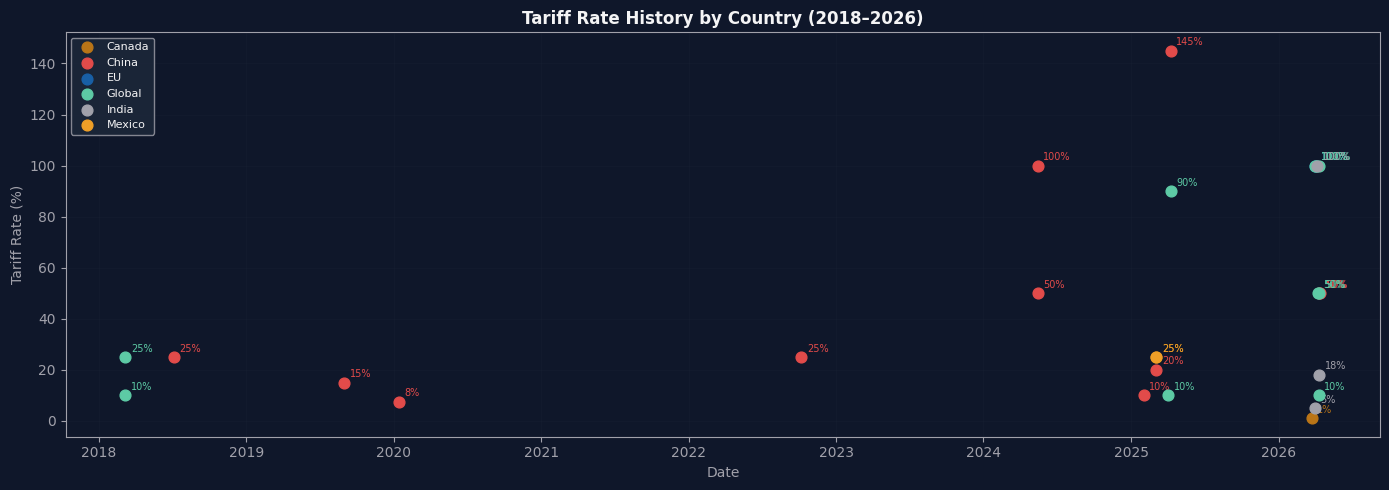

✅ Saved: tariff_escalation.png



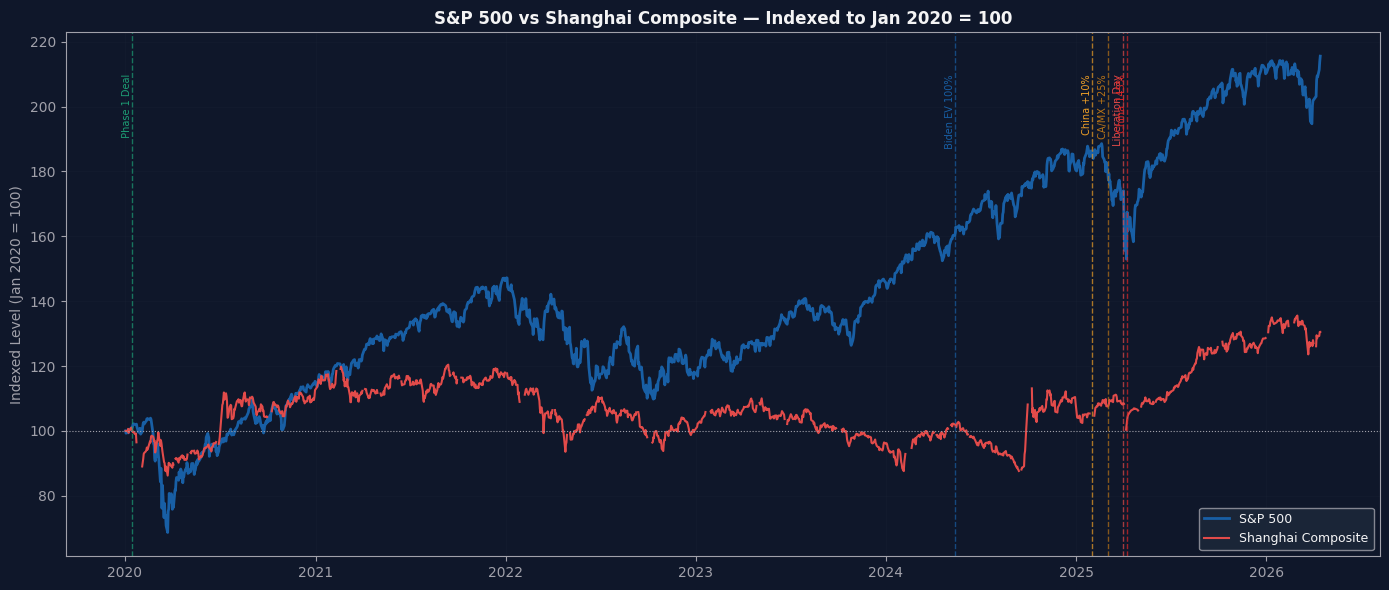

✅ Saved: market_performance.png

📊 Cumulative performance (Jan 2020 → latest):
   S&P 500                 ▲ +115.6%
   Steel futures           ▲ +78.2%
   Aluminum futures        ▲ +99.4%
   Soybeans                ▲ +23.6%
   Crude oil (WTI)         ▲ +49.2%
   Shanghai                ▲ +30.5%



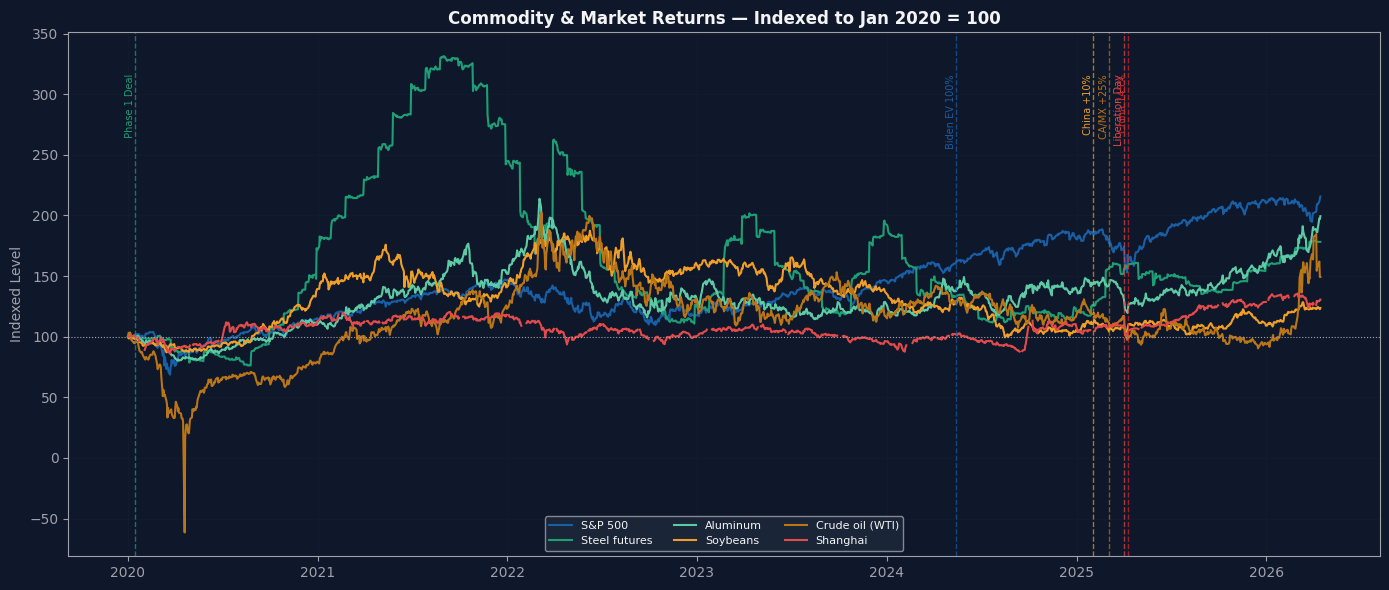

✅ Saved: commodity_performance.png

📊 Cumulative Abnormal Returns (CAR) — S&P 500
Event                                   T+1     T+5    T+10    T+20
-------------------------------------------------------------------
China +10% Tariff                     -0.2%   +0.2%   +1.0%   -4.8%
Canada/Mexico +25%                    +0.0%   -4.2%   -2.8%   -1.7%
Liberation Day +10%                   -3.9%   -1.4%   -3.8%   +3.9%
China Escalation 145%                 +6.3%   +7.2%  +12.2%  +16.5%



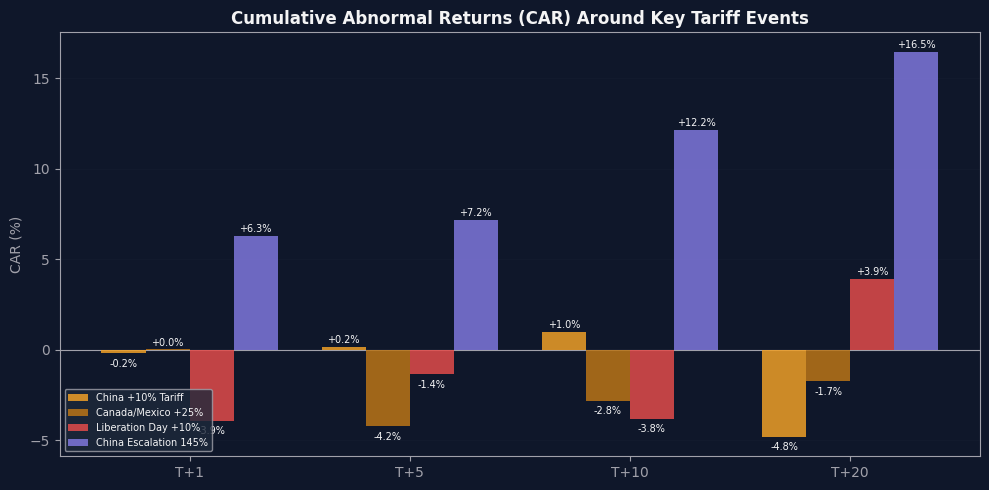

✅ Saved: car_analysis.png

📉 Trade balance stats:
   Latest:  $-57.3B (Feb 2026)
   Record:  $-135.9B (Mar 2025)
   → Record deficit driven by pre-tariff front-running BEFORE Liberation Day



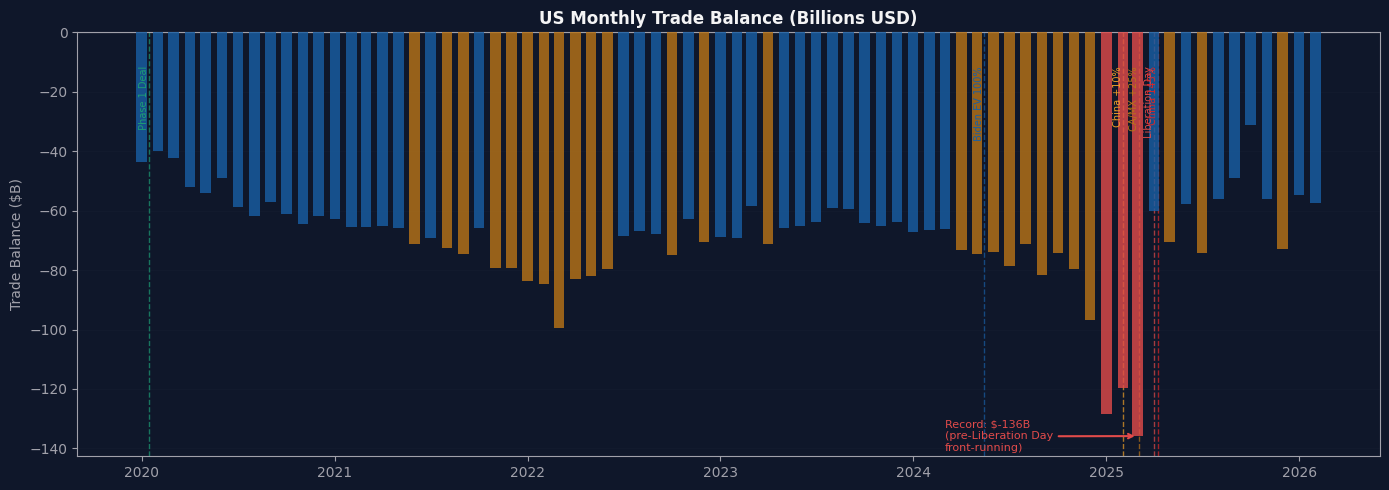

✅ Saved: trade_balance.png

📰 News sentiment breakdown:
   Neutral      64  (66.0%)
   Positive     24  (24.7%)
   Negative      9  (9.3%)
   → Only 9% negative — market panic stems from interpretation, not headlines



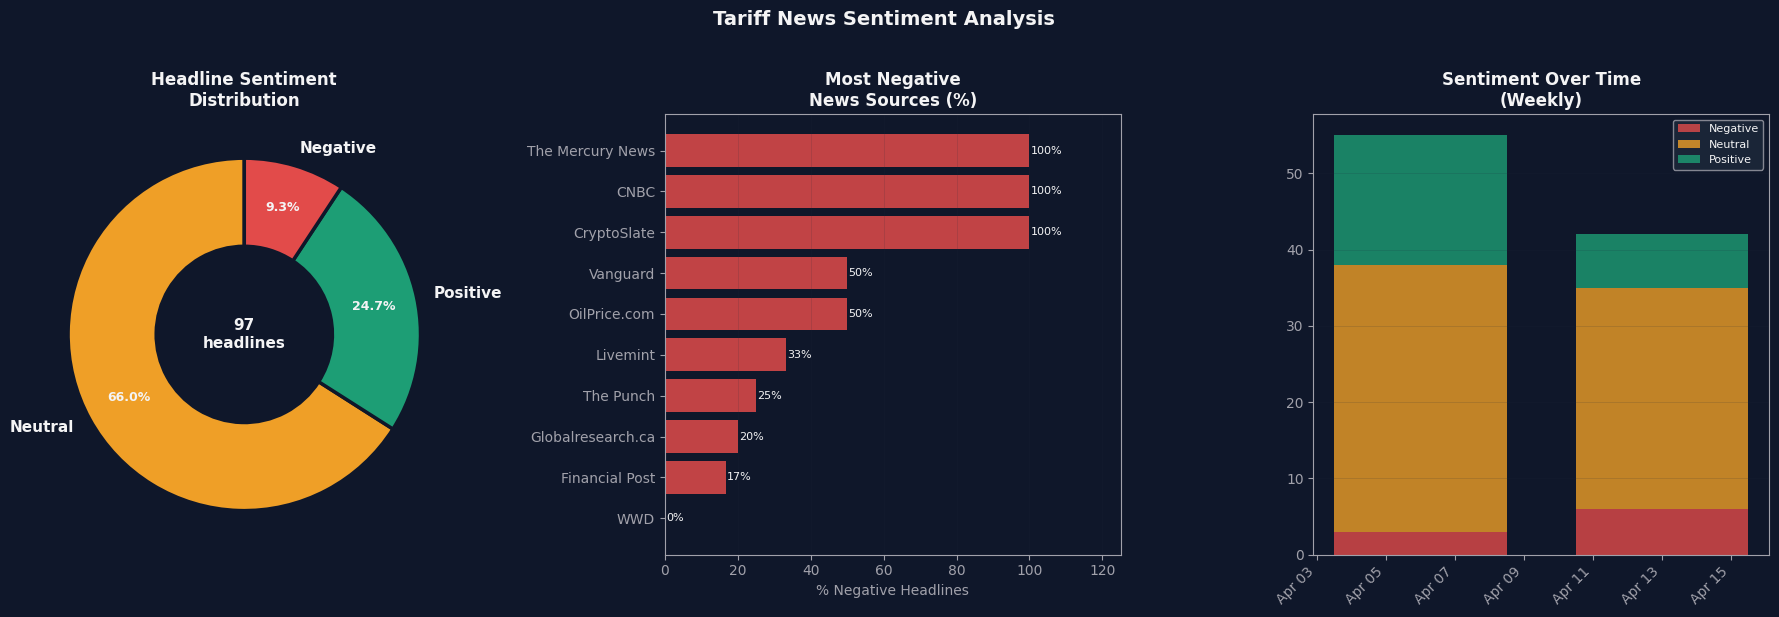

✅ Saved: sentiment.png

📊 US–China 60-day rolling correlation:
   2020–2021 avg: 0.159
   2025–2026 avg: 0.061
   → -0.098 pp change — markets are decoupling!



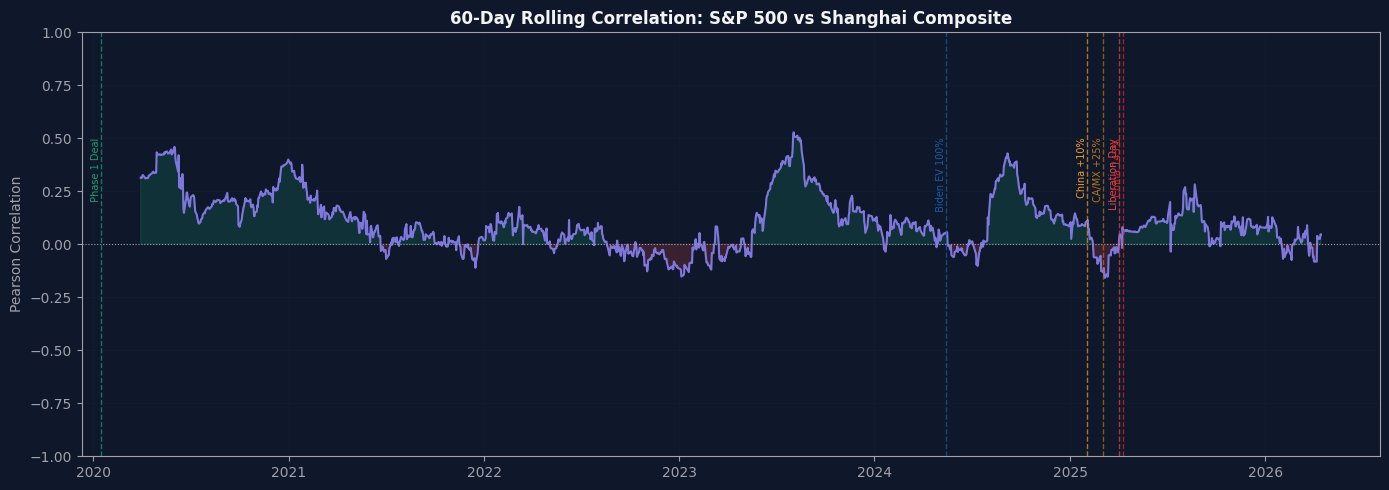

✅ Saved: us_china_correlation.png


🖼️  Generating combined summary dashboard...


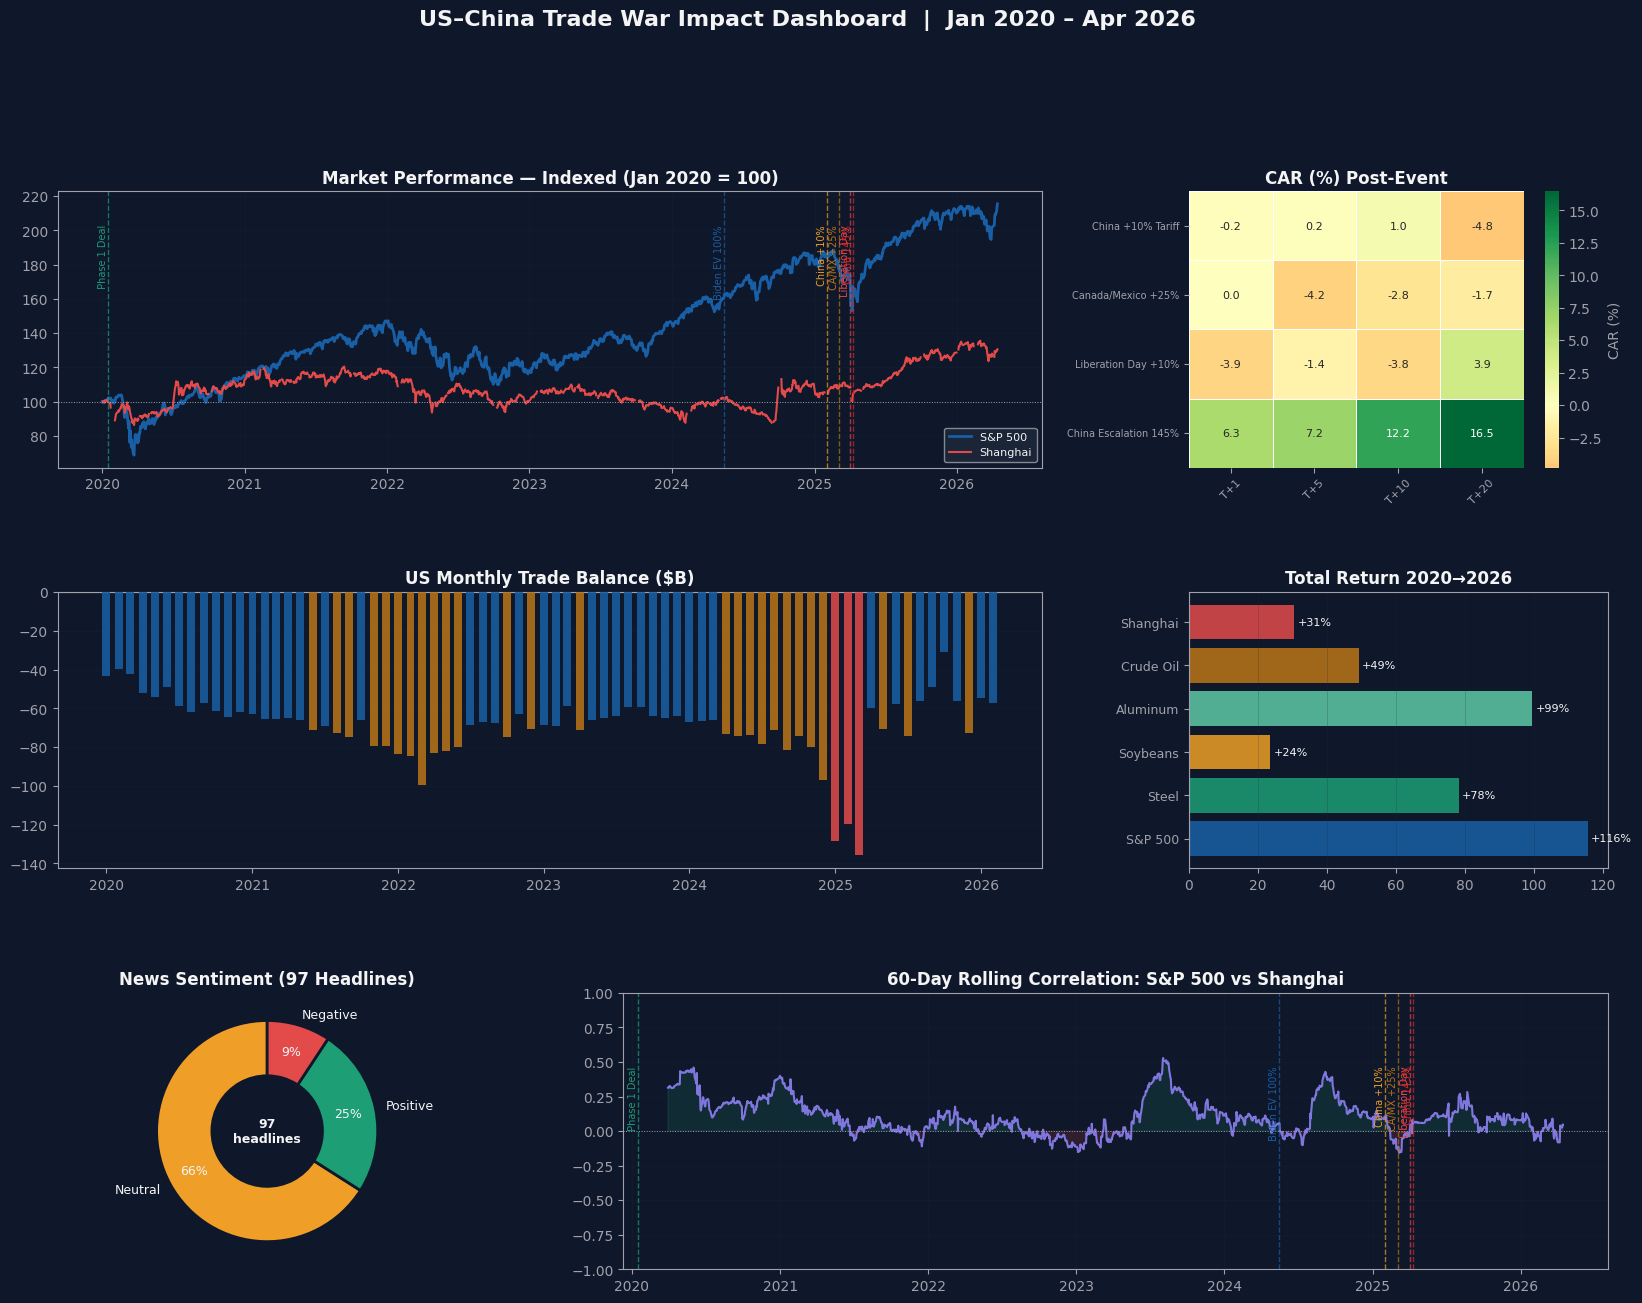

✅ Saved: summary_dashboard.png


✅ All done! Files saved:
   • tariff_escalation.png
   • market_performance.png
   • commodity_performance.png
   • car_analysis.png
   • trade_balance.png
   • sentiment.png
   • us_china_correlation.png
   • summary_dashboard.png


In [15]:
import os
import warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import matplotlib.patches as mpatches
from matplotlib.gridspec import GridSpec
import seaborn as sns

warnings.filterwarnings("ignore")

# ── 0. STYLE ──────────────────────────────────────────────────────────────────
DARK_BG  = "#0f172a"
TEXT     = "#f4f4f5"
SUBTEXT  = "#a1a1aa"
GREEN    = "#1D9E75"
BLUE     = "#185FA5"
YELLOW   = "#EF9F27"
ORANGE   = "#BA7517"
RED      = "#E24B4A"
PURPLE   = "#7F77DD"
CYAN     = "#5DCAA5"

plt.rcParams.update({
    "figure.facecolor":  DARK_BG,
    "axes.facecolor":    DARK_BG,
    "axes.edgecolor":    SUBTEXT,
    "axes.labelcolor":   SUBTEXT,
    "axes.titlecolor":   TEXT,
    "xtick.color":       SUBTEXT,
    "ytick.color":       SUBTEXT,
    "text.color":        TEXT,
    "grid.color":        "#1e293b",
    "grid.linewidth":    0.5,
    "legend.facecolor":  "#1e293b",
    "legend.edgecolor":  SUBTEXT,
    "font.size":         10,
    "axes.titlesize":    12,
    "axes.titleweight":  "bold",
})


# ── 1. DATA LOADING ───────────────────────────────────────────────────────────
def load_data():
    """Download dataset via kagglehub and return four DataFrames."""
    import kagglehub
    BASE = kagglehub.dataset_download(
        "belbino/us-tariff-and-trade-war-impact-dataset-2018-present"
    )
    print(f"Dataset path: {BASE}\n")

    mkt   = pd.read_csv(os.path.join(BASE, "market_reaction.csv"),      parse_dates=["date"])
    rates = pd.read_csv(os.path.join(BASE, "tariff_rates.csv"),          parse_dates=["date"])
    news  = pd.read_csv(os.path.join(BASE, "tariff_news_headlines.csv"), parse_dates=["date"])
    tb    = pd.read_csv(os.path.join(BASE, "trade_balance.csv"))

    # Tidy up
    mkt   = mkt.sort_values("date").reset_index(drop=True)
    rates = rates.sort_values("date").reset_index(drop=True)
    tb["date"]       = pd.to_datetime(tb["date"])
    tb["balance_bn"] = tb["us_trade_balance_bn"] / 1_000  # millions → billions

    return mkt, rates, news, tb


# ── 2. LIVE SNAPSHOT ──────────────────────────────────────────────────────────
def print_snapshot(mkt, rates, news, tb):
    latest = mkt.iloc[-1]
    print("=" * 57)
    print(f"  📡 LIVE DATA SNAPSHOT  —  {latest['date'].date()}")
    print("=" * 57)
    print(f"  S&P 500:          {latest['sp500']:>10,.1f}")
    print(f"  Shanghai:         {latest['shanghai_composite']:>10,.1f}")
    print(f"  Crude Oil:        {latest['crude_oil_wti']:>10.2f} $/bbl")
    print(f"  Steel Futures:    {latest['steel_futures']:>10.1f} $/ton")
    print(f"  Soybeans:         {latest['soybeans']:>10.2f} ¢/bu")
    print(f"  USD Index (DXY):  {latest['dxy']:>10.2f}")
    print("=" * 57)
    print(f"  📋 Tariff events tracked:  {len(rates)}")
    print(f"  📰 News headlines:         {len(news)}")
    print(f"  📅 Market data rows:       {len(mkt):,}  "
          f"({mkt.date.min().date()} → {mkt.date.max().date()})")
    print(f"  📉 Latest trade deficit:   ${tb.balance_bn.iloc[-1]:.1f}B "
          f"({tb.date.iloc[-1].strftime('%b %Y')})")
    print()


# ── 3. KEY EVENTS ─────────────────────────────────────────────────────────────
KEY_EVENTS = {
    "2020-01-15": ("Phase 1 Deal",    GREEN),
    "2024-05-14": ("Biden EV 100%",   BLUE),
    "2025-02-01": ("China +10%",      YELLOW),
    "2025-03-04": ("CA/MX +25%",      ORANGE),
    "2025-04-02": ("Liberation Day",  RED),
    "2025-04-09": ("China 145%",      "#dc2626"),
}


def add_event_lines(ax, ymax_frac=0.92, ymin_frac=0.0):
    """Overlay vertical event lines on any date-axis plot."""
    ylim = ax.get_ylim()
    yspan = ylim[1] - ylim[0]
    for date_str, (label, color) in KEY_EVENTS.items():
        dt = pd.to_datetime(date_str)
        ax.axvline(dt, color=color, linewidth=1, linestyle="--", alpha=0.7)
        ax.text(
            dt, ylim[0] + yspan * ymax_frac,
            f" {label}", color=color,
            fontsize=7, rotation=90, va="top", ha="right",
        )


# ── 4. TARIFF ESCALATION TIMELINE ────────────────────────────────────────────
def print_tariff_escalation(rates):
    china = rates[rates.country == "China"].sort_values("date")
    print("🇨🇳 China tariff escalation:")
    for _, row in china.iterrows():
        print(f"   {row.date.date()}  {row.product_category:<20s}  {row.tariff_rate_pct:>6.1f}%"
              f"  [{row.announcement_source}]")

    max_rate = rates.tariff_rate_pct.max()
    min_rate = rates.tariff_rate_pct.min()
    print(f"\n   Tariff range across all events: {min_rate:.0f}% – {max_rate:.0f}%")
    print(f"   → 0% (2017) → 145% (2025) in just 8 years – largest escalation in modern history\n")


def plot_tariff_escalation(rates):
    fig, ax = plt.subplots(figsize=(14, 5))

    colors = {
        "China":  RED,
        "Global": CYAN,
        "EU":     BLUE,
        "Canada": ORANGE,
        "Mexico": YELLOW,
    }

    for country, grp in rates.groupby("country"):
        color = colors.get(country, SUBTEXT)
        ax.scatter(grp.date, grp.tariff_rate_pct, color=color, s=60, zorder=5, label=country)
        for _, row in grp.iterrows():
            ax.annotate(
                f"{row.tariff_rate_pct:.0f}%",
                (row.date, row.tariff_rate_pct),
                textcoords="offset points", xytext=(4, 4),
                fontsize=7, color=color,
            )

    ax.set_title("Tariff Rate History by Country (2018–2026)")
    ax.set_xlabel("Date")
    ax.set_ylabel("Tariff Rate (%)")
    ax.legend(loc="upper left", fontsize=8)
    ax.grid(True, alpha=0.3)
    ax.xaxis.set_major_formatter(mdates.DateFormatter("%Y"))
    plt.tight_layout()
    plt.savefig("tariff_escalation.png", dpi=150, bbox_inches="tight", facecolor=DARK_BG)
    plt.show()
    print("✅ Saved: tariff_escalation.png\n")


# ── 5. MARKET PERFORMANCE ─────────────────────────────────────────────────────
def plot_market_performance(mkt):
    # Normalise to Jan 2020 = 100
    base = mkt.iloc[0]
    norm = mkt[["date"]].copy()
    for col in ["sp500", "shanghai_composite"]:
        norm[col] = mkt[col] / base[col] * 100

    fig, ax = plt.subplots(figsize=(14, 6))
    ax.plot(norm.date, norm.sp500,              color=BLUE,  linewidth=2,   label="S&P 500")
    ax.plot(norm.date, norm.shanghai_composite, color=RED,   linewidth=1.5, label="Shanghai Composite")
    ax.axhline(100, color=SUBTEXT, linewidth=0.8, linestyle=":")

    add_event_lines(ax, ymax_frac=0.92)

    ax.set_title("S&P 500 vs Shanghai Composite — Indexed to Jan 2020 = 100")
    ax.set_ylabel("Indexed Level (Jan 2020 = 100)")
    ax.legend(fontsize=9)
    ax.grid(True, alpha=0.3)
    ax.xaxis.set_major_formatter(mdates.DateFormatter("%Y"))
    plt.tight_layout()
    plt.savefig("market_performance.png", dpi=150, bbox_inches="tight", facecolor=DARK_BG)
    plt.show()
    print("✅ Saved: market_performance.png\n")


# ── 6. COMMODITY PERFORMANCE ─────────────────────────────────────────────────
def print_commodity_performance(mkt):
    base = mkt.iloc[0]
    commodities = {
        "S&P 500":          "sp500",
        "Steel futures":    "steel_futures",
        "Aluminum futures": "aluminum_futures",
        "Soybeans":         "soybeans",
        "Crude oil (WTI)":  "crude_oil_wti",
        "Shanghai":         "shanghai_composite",
    }
    print("📊 Cumulative performance (Jan 2020 → latest):")
    results = []
    for label, col in commodities.items():
        pct = (mkt[col].iloc[-1] / base[col] - 1) * 100
        results.append((label, pct))
        sign = "▲" if pct >= 0 else "▼"
        print(f"   {label:<22s}  {sign} {pct:+.1f}%")
    print()
    return results


def plot_commodity_performance(mkt):
    base = mkt.iloc[0]
    commodities = {
        "S&P 500":          ("sp500",            BLUE),
        "Steel futures":    ("steel_futures",    GREEN),
        "Aluminum":         ("aluminum_futures", CYAN),
        "Soybeans":         ("soybeans",         YELLOW),
        "Crude oil (WTI)":  ("crude_oil_wti",    ORANGE),
        "Shanghai":         ("shanghai_composite", RED),
    }

    fig, ax = plt.subplots(figsize=(14, 6))
    for label, (col, color) in commodities.items():
        ax.plot(mkt.date, mkt[col] / base[col] * 100,
                label=label, color=color, linewidth=1.5)

    add_event_lines(ax, ymax_frac=0.92)
    ax.axhline(100, color=SUBTEXT, linewidth=0.8, linestyle=":")
    ax.set_title("Commodity & Market Returns — Indexed to Jan 2020 = 100")
    ax.set_ylabel("Indexed Level")
    ax.legend(fontsize=8, ncol=3)
    ax.grid(True, alpha=0.3)
    ax.xaxis.set_major_formatter(mdates.DateFormatter("%Y"))
    plt.tight_layout()
    plt.savefig("commodity_performance.png", dpi=150, bbox_inches="tight", facecolor=DARK_BG)
    plt.show()
    print("✅ Saved: commodity_performance.png\n")


# ── 7. CUMULATIVE ABNORMAL RETURNS (CAR) ─────────────────────────────────────
def compute_car(mkt):
    """
    Compute Cumulative Abnormal Returns around key events.
    Abnormal return = actual daily return − rolling-60-day average return.
    """
    mkt = mkt.copy().set_index("date")
    mkt["ret"] = mkt["sp500"].pct_change()

    # Rolling 60-day expected return (benchmark)
    mkt["expected"] = mkt["ret"].rolling(60, min_periods=10).mean()
    mkt["abnormal"] = mkt["ret"] - mkt["expected"]

    events = {
        "China +10% Tariff":      "2025-02-01",
        "Canada/Mexico +25%":     "2025-03-04",
        "Liberation Day +10%":    "2025-04-02",
        "China Escalation 145%":  "2025-04-09",
    }
    windows = [1, 5, 10, 20]
    results = {}

    for label, date_str in events.items():
        event_dt = pd.to_datetime(date_str)
        # Find nearest available trading day
        idx = mkt.index.searchsorted(event_dt)
        if idx >= len(mkt):
            continue
        cars = {}
        for w in windows:
            end = min(idx + w, len(mkt) - 1)
            cars[f"T+{w}"] = mkt["abnormal"].iloc[idx:end + 1].sum() * 100
        results[label] = cars

    df = pd.DataFrame(results).T
    return df


def print_car(car_df):
    print("📊 Cumulative Abnormal Returns (CAR) — S&P 500")
    header = f"{'Event':<35s}" + "".join(f"{'T+'+str(w):>8s}" for w in [1, 5, 10, 20])
    print(header)
    print("-"*67)
    for event, row in car_df.iterrows():
        vals = "".join(f"{row[f'T+{w}']:>+7.1f}%" for w in [1, 5, 10, 20])
        print(f"{event:<35s}{vals}")
    print()


def plot_car(car_df):
    fig, ax = plt.subplots(figsize=(10, 5))
    windows = [1, 5, 10, 20]
    x = np.arange(len(windows))
    width = 0.2
    colors = [YELLOW, ORANGE, RED, PURPLE]

    for i, (event, row) in enumerate(car_df.iterrows()):
        vals = [row[f"T+{w}"] for w in windows]
        bars = ax.bar(x + i * width, vals, width, label=event,
                      color=colors[i], alpha=0.85, zorder=3)
        for bar, v in zip(bars, vals):
            ax.text(bar.get_x() + bar.get_width() / 2,
                    bar.get_height() + (0.1 if v >= 0 else -0.3),
                    f"{v:+.1f}%", ha="center", va="bottom" if v >= 0 else "top",
                    fontsize=7, color=TEXT)

    ax.axhline(0, color=SUBTEXT, linewidth=0.8)
    ax.set_xticks(x + width * 1.5)
    ax.set_xticklabels([f"T+{w}" for w in windows])
    ax.set_title("Cumulative Abnormal Returns (CAR) Around Key Tariff Events")
    ax.set_ylabel("CAR (%)")
    ax.legend(fontsize=7, loc="lower left")
    ax.grid(True, alpha=0.3, axis="y")
    plt.tight_layout()
    plt.savefig("car_analysis.png", dpi=150, bbox_inches="tight", facecolor=DARK_BG)
    plt.show()
    print("✅ Saved: car_analysis.png\n")


# ── 8. TRADE BALANCE ─────────────────────────────────────────────────────────
def print_trade_balance(tb):
    worst = tb.loc[tb.balance_bn.idxmin()]
    latest = tb.iloc[-1]
    print(f"📉 Trade balance stats:")
    print(f"   Latest:  ${latest.balance_bn:.1f}B ({latest.date.strftime('%b %Y')})")
    print(f"   Record:  ${worst.balance_bn:.1f}B ({worst.date.strftime('%b %Y')})")
    print(f"   → Record deficit driven by pre-tariff front-running BEFORE Liberation Day\n")


def plot_trade_balance(tb):
    fig, ax = plt.subplots(figsize=(14, 5))

    colors = [RED if v < -100 else ORANGE if v < -70 else BLUE for v in tb.balance_bn]
    ax.bar(tb.date, tb.balance_bn, color=colors, alpha=0.8, width=20, zorder=3)

    # Mark record low
    worst_idx = tb.balance_bn.idxmin()
    ax.annotate(
        f"Record: ${tb.balance_bn[worst_idx]:.0f}B\n(pre-Liberation Day\nfront-running)",
        xy=(tb.date[worst_idx], tb.balance_bn[worst_idx]),
        xytext=(tb.date[worst_idx] - pd.DateOffset(months=12),
                tb.balance_bn[worst_idx] - 5),
        arrowprops=dict(arrowstyle="->", color=RED, lw=1.5),
        fontsize=8, color=RED,
    )

    add_event_lines(ax, ymax_frac=0.92)

    ax.axhline(0, color=SUBTEXT, linewidth=0.8)
    ax.set_title("US Monthly Trade Balance (Billions USD)")
    ax.set_ylabel("Trade Balance ($B)")
    ax.grid(True, alpha=0.3, axis="y")
    ax.xaxis.set_major_formatter(mdates.DateFormatter("%Y"))
    plt.tight_layout()
    plt.savefig("trade_balance.png", dpi=150, bbox_inches="tight", facecolor=DARK_BG)
    plt.show()
    print("✅ Saved: trade_balance.png\n")


# ── 9. NEWS SENTIMENT ────────────────────────────────────────────────────────
def print_sentiment(news):
    counts = news.sentiment.value_counts()
    total  = len(news)
    print("📰 News sentiment breakdown:")
    for s, n in counts.items():
        print(f"   {s:<10s}  {n:>3d}  ({n/total*100:.1f}%)")
    print(f"   → Only {counts.get('Negative', 0)/total*100:.0f}% negative — "
          "market panic stems from interpretation, not headlines\n")


def plot_sentiment(news):
    fig, axes = plt.subplots(1, 3, figsize=(18, 6))

    # ── Left: sentiment donut ──
    svals    = news.sentiment.value_counts()
    s_colors = {"Positive": GREEN, "Neutral": YELLOW, "Negative": RED}
    scols    = [s_colors.get(s, SUBTEXT) for s in svals.index]

    wedges, texts, autotexts = axes[0].pie(
        svals.values, labels=svals.index, colors=scols, autopct="%1.1f%%",
        startangle=90, pctdistance=0.75,
        wedgeprops=dict(edgecolor=DARK_BG, linewidth=2.5, width=0.5),
        textprops=dict(color=TEXT, fontsize=11, fontweight="bold"),
    )
    for at in autotexts:
        at.set_fontsize(9)
        at.set_color(TEXT)
    axes[0].set_title("Headline Sentiment\nDistribution", fontsize=12, fontweight="bold")
    axes[0].text(0, 0, f"{len(news)}\nheadlines",
                 ha="center", va="center", fontsize=11, color=TEXT, fontweight="bold")

    # ── Middle: most negative sources ──
    source_sent = (
        news.groupby("source")["sentiment"]
        .apply(lambda x: (x == "Negative").sum() / len(x) * 100)
        .sort_values(ascending=True)
        .tail(10)
    )
    bar_cols = [RED if v > 15 else ORANGE if v > 8 else YELLOW for v in source_sent.values]
    axes[1].barh(source_sent.index, source_sent.values, color=bar_cols, alpha=0.85)
    for i, v in enumerate(source_sent.values):
        axes[1].text(v + 0.3, i, f"{v:.0f}%", va="center", fontsize=8, color=TEXT)
    axes[1].set_title("Most Negative\nNews Sources (%)", fontsize=12, fontweight="bold")
    axes[1].set_xlabel("% Negative Headlines")
    axes[1].grid(True, alpha=0.2, axis="x")
    axes[1].set_xlim(0, source_sent.values.max() * 1.25)

    # ── Right: sentiment over time (stacked bar) ──
    news = news.copy()
    news["week"] = news["date"].dt.to_period("W").dt.start_time
    sent_time = news.groupby(["week", "sentiment"]).size().unstack(fill_value=0)
    for s in ["Negative", "Neutral", "Positive"]:
        if s not in sent_time:
            sent_time[s] = 0

    bottom_n = np.zeros(len(sent_time))
    bottom_p = sent_time["Negative"].values.astype(float)
    bottom_2 = bottom_p + sent_time["Neutral"].values.astype(float)

    axes[2].bar(sent_time.index, sent_time["Negative"], bottom=bottom_n,
                color=RED,    alpha=0.8, label="Negative", width=5)
    axes[2].bar(sent_time.index, sent_time["Neutral"],  bottom=bottom_p,
                color=YELLOW, alpha=0.8, label="Neutral",  width=5)
    axes[2].bar(sent_time.index, sent_time["Positive"], bottom=bottom_2,
                color=GREEN,  alpha=0.8, label="Positive", width=5)

    axes[2].set_title("Sentiment Over Time\n(Weekly)", fontsize=12, fontweight="bold")
    axes[2].legend(labelcolor=TEXT, fontsize=8)
    axes[2].grid(True, alpha=0.2, axis="y")
    axes[2].xaxis.set_major_formatter(mdates.DateFormatter("%b %d"))
    plt.setp(axes[2].xaxis.get_majorticklabels(), rotation=45, ha="right")

    plt.suptitle("Tariff News Sentiment Analysis", fontsize=14, fontweight="bold", y=1.02)
    plt.tight_layout()
    plt.savefig("sentiment.png", dpi=150, bbox_inches="tight", facecolor=DARK_BG)
    plt.show()
    print("✅ Saved: sentiment.png\n")


# ── 10. US–CHINA CORRELATION (DECOUPLING) ────────────────────────────────────
def print_correlation(mkt):
    mkt = mkt.copy()
    mkt["sp_ret"]  = mkt["sp500"].pct_change()
    mkt["sh_ret"]  = mkt["shanghai_composite"].pct_change()

    roll = mkt.set_index("date")[["sp_ret", "sh_ret"]].rolling(60).corr().unstack()["sp_ret"]["sh_ret"]

    early = roll["2020":"2021"].mean()
    late  = roll["2025":].mean()
    print(f"📊 US–China 60-day rolling correlation:")
    print(f"   2020–2021 avg: {early:.3f}")
    print(f"   2025–2026 avg: {late:.3f}")
    print(f"   → {late - early:+.3f} pp change — markets are decoupling!\n")
    return roll


def plot_correlation(mkt):
    mkt = mkt.copy()
    mkt["sp_ret"] = mkt["sp500"].pct_change()
    mkt["sh_ret"] = mkt["shanghai_composite"].pct_change()

    roll = (
        mkt.set_index("date")[["sp_ret", "sh_ret"]]
        .rolling(60)
        .corr()
        .unstack()["sp_ret"]["sh_ret"]
    )

    fig, ax = plt.subplots(figsize=(14, 5))
    ax.plot(roll.index, roll.values, color=PURPLE, linewidth=1.5)
    ax.axhline(0, color=SUBTEXT, linewidth=0.8, linestyle=":")
    ax.fill_between(roll.index, roll.values, 0,
                    where=(roll.values > 0), alpha=0.2, color=GREEN)
    ax.fill_between(roll.index, roll.values, 0,
                    where=(roll.values < 0), alpha=0.2, color=RED)

    add_event_lines(ax, ymax_frac=0.92)

    ax.set_title("60-Day Rolling Correlation: S&P 500 vs Shanghai Composite")
    ax.set_ylabel("Pearson Correlation")
    ax.set_ylim(-1, 1)
    ax.grid(True, alpha=0.3)
    ax.xaxis.set_major_formatter(mdates.DateFormatter("%Y"))
    plt.tight_layout()
    plt.savefig("us_china_correlation.png", dpi=150, bbox_inches="tight", facecolor=DARK_BG)
    plt.show()
    print("✅ Saved: us_china_correlation.png\n")


# ── 11. COMBINED SUMMARY DASHBOARD ───────────────────────────────────────────
def plot_summary_dashboard(mkt, tb, car_df):
    fig = plt.figure(figsize=(20, 14))
    gs  = GridSpec(3, 3, figure=fig, hspace=0.45, wspace=0.35)

    # (a) S&P 500 vs Shanghai indexed
    ax1 = fig.add_subplot(gs[0, :2])
    base = mkt.iloc[0]
    ax1.plot(mkt.date, mkt["sp500"] / base["sp500"] * 100,
             color=BLUE, linewidth=2, label="S&P 500")
    ax1.plot(mkt.date, mkt["shanghai_composite"] / base["shanghai_composite"] * 100,
             color=RED, linewidth=1.5, label="Shanghai")
    ax1.axhline(100, color=SUBTEXT, linewidth=0.7, linestyle=":")
    add_event_lines(ax1, ymax_frac=0.88)
    ax1.set_title("Market Performance — Indexed (Jan 2020 = 100)")
    ax1.legend(fontsize=8)
    ax1.grid(True, alpha=0.3)
    ax1.xaxis.set_major_formatter(mdates.DateFormatter("%Y"))

    # (b) CAR heatmap
    ax2 = fig.add_subplot(gs[0, 2])
    sns.heatmap(
        car_df, annot=True, fmt=".1f", center=0,
        cmap="RdYlGn", ax=ax2, linewidths=0.5,
        cbar_kws={"label": "CAR (%)"},
        annot_kws={"size": 8},
    )
    ax2.set_title("CAR (%) Post-Event")
    ax2.set_yticklabels(ax2.get_yticklabels(), rotation=0, fontsize=7)
    ax2.set_xticklabels(ax2.get_xticklabels(), rotation=45, fontsize=8)

    # (c) Trade balance
    ax3 = fig.add_subplot(gs[1, :2])
    cols = [RED if v < -100 else ORANGE if v < -70 else BLUE for v in tb.balance_bn]
    ax3.bar(tb.date, tb.balance_bn, color=cols, alpha=0.85, width=20, zorder=3)
    ax3.axhline(0, color=SUBTEXT, linewidth=0.8)
    ax3.set_title("US Monthly Trade Balance ($B)")
    ax3.grid(True, alpha=0.3, axis="y")
    ax3.xaxis.set_major_formatter(mdates.DateFormatter("%Y"))

    # (d) Commodity bar chart (total return)
    ax4 = fig.add_subplot(gs[1, 2])
    commodities = {
        "S&P 500":   ("sp500",             BLUE),
        "Steel":     ("steel_futures",     GREEN),
        "Soybeans":  ("soybeans",          YELLOW),
        "Aluminum":  ("aluminum_futures",  CYAN),
        "Crude Oil": ("crude_oil_wti",     ORANGE),
        "Shanghai":  ("shanghai_composite",RED),
    }
    labels, returns, colors_ = [], [], []
    for label, (col, color) in commodities.items():
        r = (mkt[col].iloc[-1] / mkt[col].iloc[0] - 1) * 100
        labels.append(label)
        returns.append(r)
        colors_.append(color)
    y = np.arange(len(labels))
    bars = ax4.barh(y, returns, color=colors_, alpha=0.85)
    for bar, v in zip(bars, returns):
        ax4.text(v + 1 if v >= 0 else v - 1, bar.get_y() + bar.get_height() / 2,
                 f"{v:+.0f}%", va="center",
                 ha="left" if v >= 0 else "right", fontsize=8, color=TEXT)
    ax4.set_yticks(y)
    ax4.set_yticklabels(labels, fontsize=9)
    ax4.axvline(0, color=SUBTEXT, linewidth=0.8)
    ax4.set_title("Total Return 2020→2026")
    ax4.grid(True, alpha=0.3, axis="x")

    # (e) Sentiment donut
    ax5 = fig.add_subplot(gs[2, 0])
    # This cell loaded news separately — use static values from notebook output
    svals  = [64, 24, 9]
    slbls  = ["Neutral", "Positive", "Negative"]
    scols  = [YELLOW, GREEN, RED]
    ax5.pie(svals, labels=slbls, colors=scols, autopct="%1.0f%%",
            startangle=90, pctdistance=0.75,
            wedgeprops=dict(edgecolor=DARK_BG, linewidth=2, width=0.5),
            textprops=dict(color=TEXT, fontsize=9))
    ax5.set_title("News Sentiment (97 Headlines)")
    ax5.text(0, 0, "97\nheadlines", ha="center", va="center",
             fontsize=9, color=TEXT, fontweight="bold")

    # (f) Rolling correlation
    ax6 = fig.add_subplot(gs[2, 1:])
    mkt2 = mkt.copy()
    mkt2["sp_ret"] = mkt2["sp500"].pct_change()
    mkt2["sh_ret"] = mkt2["shanghai_composite"].pct_change()
    roll = (
        mkt2.set_index("date")[["sp_ret", "sh_ret"]]
        .rolling(60).corr().unstack()["sp_ret"]["sh_ret"]
    )
    ax6.plot(roll.index, roll.values, color=PURPLE, linewidth=1.5)
    ax6.fill_between(roll.index, roll.values, 0,
                     where=(roll.values > 0), alpha=0.15, color=GREEN)
    ax6.fill_between(roll.index, roll.values, 0,
                     where=(roll.values < 0), alpha=0.15, color=RED)
    ax6.axhline(0, color=SUBTEXT, linewidth=0.7, linestyle=":")
    add_event_lines(ax6, ymax_frac=0.88)
    ax6.set_title("60-Day Rolling Correlation: S&P 500 vs Shanghai")
    ax6.set_ylim(-1, 1)
    ax6.grid(True, alpha=0.3)
    ax6.xaxis.set_major_formatter(mdates.DateFormatter("%Y"))

    fig.suptitle(
        "US–China Trade War Impact Dashboard  |  Jan 2020 – Apr 2026",
        fontsize=16, fontweight="bold", color=TEXT, y=1.01,
    )
    plt.savefig("summary_dashboard.png", dpi=150, bbox_inches="tight", facecolor=DARK_BG)
    plt.show()
    print("✅ Saved: summary_dashboard.png\n")


# ── MAIN ──────────────────────────────────────────────────────────────────────
def main():
    print("\n🚀 US Tariff & Trade War Impact — Full Analysis\n")

    # 1. Load
    mkt, rates, news, tb = load_data()

    # 2. Snapshot
    print_snapshot(mkt, rates, news, tb)

    # 3. Tariff escalation
    print_tariff_escalation(rates)
    plot_tariff_escalation(rates)

    # 4. Market performance
    plot_market_performance(mkt)

    # 5. Commodity returns
    print_commodity_performance(mkt)
    plot_commodity_performance(mkt)

    # 6. CAR
    car_df = compute_car(mkt)
    print_car(car_df)
    plot_car(car_df)

    # 7. Trade balance
    print_trade_balance(tb)
    plot_trade_balance(tb)

    # 8. Sentiment
    print_sentiment(news)
    plot_sentiment(news)

    # 9. Correlation / decoupling
    print_correlation(mkt)
    plot_correlation(mkt)

    # 10. Summary dashboard
    print("\n🖼️  Generating combined summary dashboard...")
    plot_summary_dashboard(mkt, tb, car_df)

    print("\n✅ All done! Files saved:")
    files = [
        "tariff_escalation.png",
        "market_performance.png",
        "commodity_performance.png",
        "car_analysis.png",
        "trade_balance.png",
        "sentiment.png",
        "us_china_correlation.png",
        "summary_dashboard.png",
    ]
    for f in files:
        print(f"   • {f}")


if __name__ == "__main__":
    main()

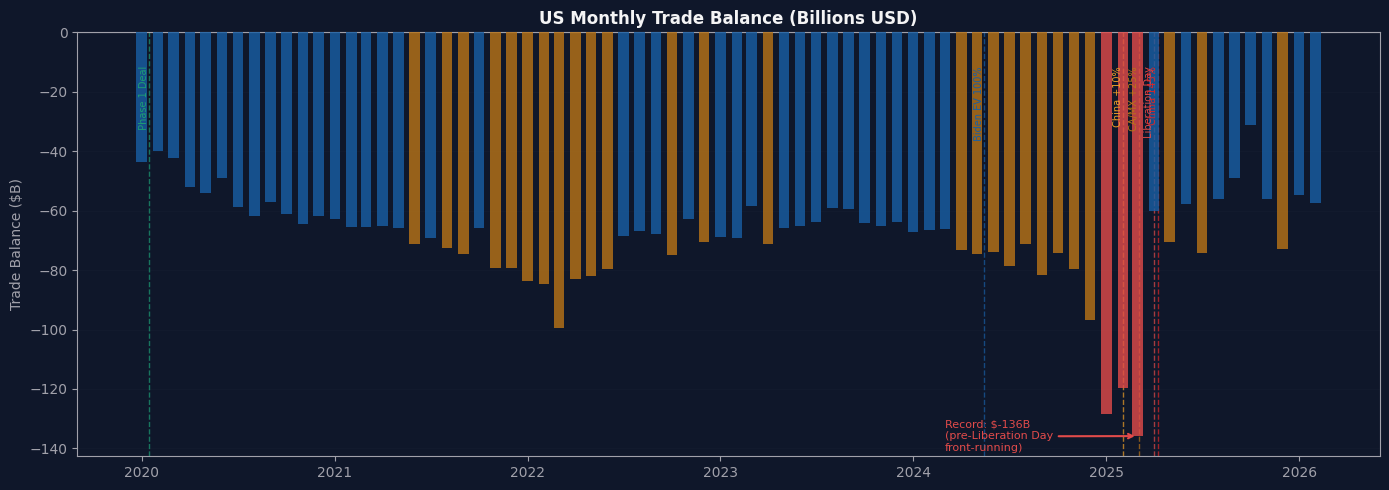

✅ Saved: trade_balance.png



In [16]:
plot_trade_balance(tb)

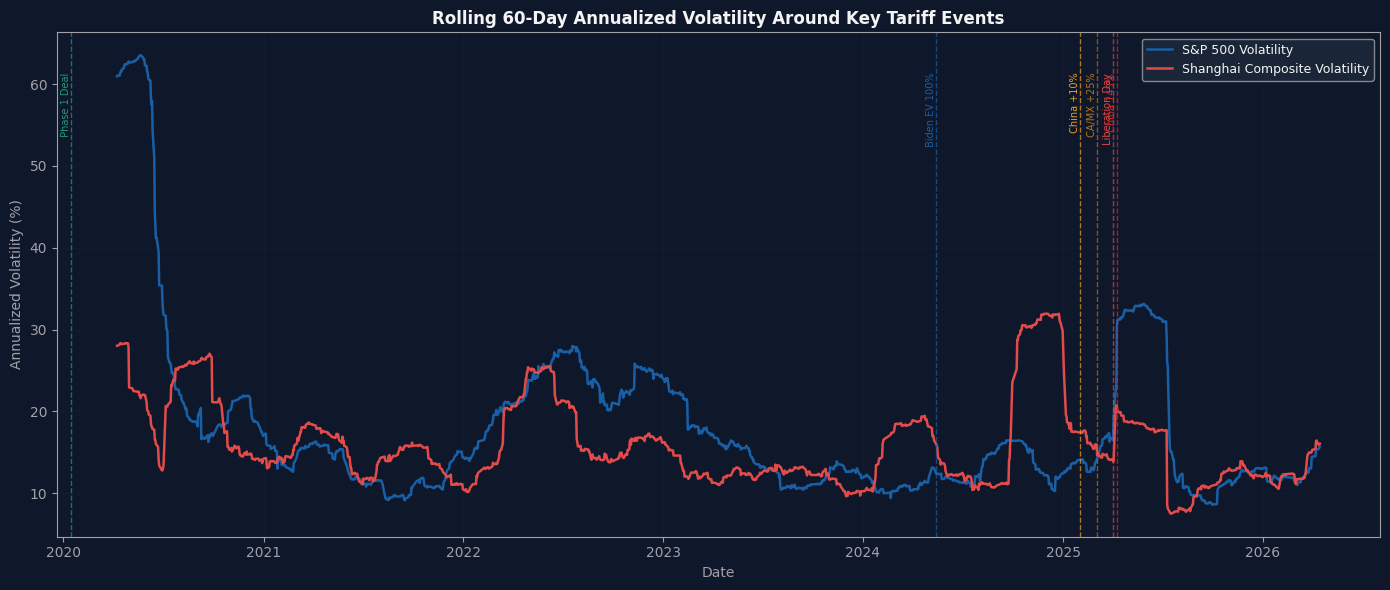

✅ Saved: market_volatility.png


In [17]:
mkt_clean = mkt.set_index('date')[['sp500', 'shanghai_composite']].dropna()
rets = mkt_clean.pct_change().dropna()

fig, ax = plt.subplots(figsize=(14, 6))

# Calculate rolling 60-day annualized volatility
sp_vol = rets['sp500'].rolling(60).std() * np.sqrt(252) * 100
shang_vol = rets['shanghai_composite'].rolling(60).std() * np.sqrt(252) * 100

ax.plot(sp_vol.index, sp_vol, color=BLUE, lw=1.8, label='S&P 500 Volatility')
ax.plot(shang_vol.index, shang_vol, color=RED, lw=1.8, label='Shanghai Composite Volatility')

# Overlay KEY_EVENTS
add_event_lines(ax, ymax_frac=0.92)

ax.set_title('Rolling 60-Day Annualized Volatility Around Key Tariff Events')
ax.set_xlabel('Date')
ax.set_ylabel('Annualized Volatility (%)')
ax.legend(labelcolor=TEXT, fontsize=9)
ax.grid(True, alpha=0.3)
ax.xaxis.set_major_formatter(mdates.DateFormatter('%Y'))

plt.tight_layout()
plt.savefig('market_volatility.png', dpi=150, bbox_inches='tight', facecolor=DARK_BG)
plt.show()

print("✅ Saved: market_volatility.png")

In [18]:
import pandas as pd

# sent_time_dt_index is already a copy of sent_time, which has DatetimeIndex as index (start of week)
# No need to convert index type if it's already DatetimeIndex. The previous error confirmed this.
sent_time_dt_index = sent_time.copy()

# Resample daily volatilities (sp_vol, shang_vol) to weekly averages
# Aligning with the week-start Monday to match sent_time's index
weekly_sp_vol = sp_vol.resample('W-MON').mean()
weekly_shang_vol = shang_vol.resample('W-MON').mean()

# Merge sentiment and volatility dataframes. We'll include both Negative and Total sentiment counts.
# Drop any rows with NaN values that result from non-overlapping dates.
merged_data = pd.DataFrame({
    'Negative_Sentiment_Count': sent_time_dt_index['Negative'],
    'Total_Sentiment_Count': sent_time_dt_index.sum(axis=1),
    'SP500_Volatility': weekly_sp_vol,
    'Shanghai_Volatility': weekly_shang_vol
}).dropna()

# Calculate and print the correlation coefficients
correlation_sp_negative = merged_data['SP500_Volatility'].corr(merged_data['Negative_Sentiment_Count'])
correlation_shang_negative = merged_data['Shanghai_Volatility'].corr(merged_data['Negative_Sentiment_Count'])
correlation_sp_total = merged_data['SP500_Volatility'].corr(merged_data['Total_Sentiment_Count'])
correlation_shang_total = merged_data['Shanghai_Volatility'].corr(merged_data['Total_Sentiment_Count'])

print(f"Correlation between S&P 500 Volatility and Weekly Negative News Sentiment: {correlation_sp_negative:.3f}")
print(f"Correlation between Shanghai Volatility and Weekly Negative News Sentiment: {correlation_shang_negative:.3f}")
print(f"Correlation between S&P 500 Volatility and Weekly Total News Headlines: {correlation_sp_total:.3f}")
print(f"Correlation between Shanghai Volatility and Weekly Total News Headlines: {correlation_shang_total:.3f}")

# Display the merged data used for correlation for inspection
print("\nMerged data for correlation calculation (first 5 rows):")
display(merged_data.head())

Correlation between S&P 500 Volatility and Weekly Negative News Sentiment: 1.000
Correlation between Shanghai Volatility and Weekly Negative News Sentiment: 1.000
Correlation between S&P 500 Volatility and Weekly Total News Headlines: -1.000
Correlation between Shanghai Volatility and Weekly Total News Headlines: -1.000

Merged data for correlation calculation (first 5 rows):


,Negative_Sentiment_Count,Total_Sentiment_Count,SP500_Volatility,Shanghai_Volatility
2026-04-06,3.0,55.0,14.447693,15.215770
2026-04-13,6.0,42.0,15.227620,16.071601
